<a href="https://colab.research.google.com/github/Juli-Kareva/Fraud-detection-MDS/blob/main/Prototypical_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.9 MB/s eta 0:00:00


### Настройка гиперпараметров с помощью Optuna

Мы используем Optuna для автоматического поиска оптимальных гиперпараметров для модели ProtoNet-S (v1). Будут настроены следующие параметры:

*   **Learning Rate (lr)**: Скорость обучения оптимизатора Adam.
*   **Encoder Hidden Dimension (hidden_dim)**: Размер скрытого слоя энкодера.
*   **Encoder Embedding Dimension (embed_dim)**: Размерность выходного эмбеддинга энкодера.
*   **Focal Loss Alpha (focal_loss_alpha)**: Параметр $\alpha$ для Focal Loss, управляющий весом положительного класса.
*   **Focal Loss Gamma (focal_loss_gamma)**: Параметр $\gamma$ для Focal Loss, влияющий на снижение веса легко классифицируемых примеров.

В качестве целевой метрики для оптимизации будет использоваться PR-AUC на тестовом наборе данных (X_test, y_test), которую Optuna будет стремиться максимизировать (мы минимизируем 1 - PR-AUC).

# Prototypical Networks

**Цель:** обучить мета-модель на Base.csv (train), затем оценить адаптацию на Variants I–VI.  
**Архитектура:**
- Meta-train: сэмплируем мини-эпизоды (2-way K-shot) из `train_clean.csv`
- Meta-test: один эпизод = один Variant целиком (support set → прототипы → оценка на query)

**Зависимости от предыдущих ноутбуков:** `train_clean.csv`, `test_clean.csv`, `oot_clean.csv`, `Variant_I_clean.csv` … `Variant_VI_clean.csv`, `scaler_baseline.pkl`

## Установка зависимостей

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import pickle
import random
import os
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Воспроизводимость
SEED = 1208
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')

Устройство: cuda


## Загрузка данных

In [ ]:
FEATURES = [
    'name_email_similarity', 'session_length_in_minutes', 'zip_count_4w',
    'velocity_6h', 'credit_risk_score', 'zip_count_4w_clean',
    'current_address_months_count_clean', 'date_of_birth_distinct_emails_4w',
    'bank_branch_count_8w_clean', 'bank_months_count', 'income',
    'proposed_credit_limit', 'customer_age', 'device_os_windows',
    'email_is_free', 'phone_home_valid', 'keep_alive_session',
    'phone_mobile_valid', 'housing_status_BC', 'payment_type_AB',
    'payment_type_AC', 'housing_status_BB', 'foreign_request',
    'payment_type_AD', 'has_other_cards', 'prev_address_months_count_clean',
    'employment_status_CB', 'employment_status_CC', 'device_os_other',
    'device_os_macintosh', 'housing_status_BE', 'housing_status_BD',
    'source_TELEAPP', 'employment_status_CD', 'device_os_x11'
]
TARGET = 'fraud_bool'
INPUT_DIM = len(FEATURES)  # 35

DATA_DIR = '/content/'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'df_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'df_test.csv'))
oot_df   = pd.read_csv(os.path.join(DATA_DIR, 'df_oot.csv'))

VARIANT_NAMES = ['I', 'II', 'III', 'IV', 'V']

variants = {}
for v in VARIANT_NAMES:
    variants[v] = pd.read_csv(os.path.join(DATA_DIR, f'{DATA_DIR}Variant {v}.csv'))

print(f'Train: {len(train_df):,} строк | фродов: {train_df[TARGET].mean():.2%}')
print(f'Test:  {len(test_df):,} строк  | фродов: {test_df[TARGET].mean():.2%}')
print(f'OOT:   {len(oot_df):,} строк  | фродов: {oot_df[TARGET].mean():.2%}')
for name, df in variants.items():
    print(f'Variant {name}: {len(df):,} строк | фродов: {df[TARGET].mean():.2%}')

Train: 675,666 строк | фродов: 1.00%
Test:  119,323 строк  | фродов: 1.18%
OOT:   205,011 строк  | фродов: 1.40%
Variant I: 1,000,000 строк | фродов: 1.10%
Variant II: 1,000,000 строк | фродов: 1.10%
Variant III: 1,000,000 строк | фродов: 1.10%
Variant IV: 1,000,000 строк | фродов: 1.10%
Variant V: 1,000,000 строк | фродов: 1.10%


In [ ]:
import joblib

scaler = joblib.load(os.path.join(DATA_DIR, 'scaler_baseline.pkl'))

def scale(df, features=FEATURES):
    """Применяет baseline-скейлер к DataFrame, возвращает numpy array."""
    return scaler.transform(df[features].values)

X_train = scale(train_df)
y_train = train_df[TARGET].values

X_test  = scale(test_df)
y_test  = test_df[TARGET].values

X_oot   = scale(oot_df)
y_oot   = oot_df[TARGET].values

X_variants = {name: scale(df) for name, df in variants.items()}
y_variants = {name: df[TARGET].values for name, df in variants.items()}

print(f'X_train shape: {X_train.shape}')

X_train shape: (675666, 35)


## Проверка и дочистка данных

In [ ]:
nan_cols = train_df[FEATURES].isnull().sum()
nan_cols = nan_cols[nan_cols > 0].sort_values(ascending=False)
print('Признаки с NaN в train_clean:')
print(nan_cols)

Признаки с NaN в train_clean:
prev_address_months_count_clean       469907
current_address_months_count_clean      2827
velocity_6h                                9
dtype: int64


In [ ]:
FILL_MINUS1 = ['prev_address_months_count_clean']
FILL_MEDIAN  = ['current_address_months_count_clean', 'velocity_6h']

# Считаем медианы по train
medians = train_df[FILL_MEDIAN].median()
print('Медианы по train:')
print(medians)

def fix_nan(df):
    df = df.copy()
    for col in FILL_MINUS1:
        if col in df.columns:
            df[col] = df[col].fillna(-1)
    for col in FILL_MEDIAN:
        if col in df.columns:
            df[col] = df[col].fillna(medians[col])
    return df

train_df = fix_nan(train_df)
test_df  = fix_nan(test_df)
oot_df   = fix_nan(oot_df)
variants = {name: fix_nan(df) for name, df in variants.items()}

# Проверка
remaining = train_df[FEATURES].isnull().sum().sum()
print(f'\nNaN в train после дочистки: {remaining}')

X_train    = scaler.transform(train_df[FEATURES].values)
X_test     = scaler.transform(test_df[FEATURES].values)
X_oot      = scaler.transform(oot_df[FEATURES].values)
X_variants = {name: scaler.transform(df[FEATURES].values) for name, df in variants.items()}

y_train    = train_df[TARGET].values
y_test     = test_df[TARGET].values
y_oot      = oot_df[TARGET].values
y_variants = {name: df[TARGET].values for name, df in variants.items()}

print('NaN в X_train:', np.isnan(X_train).any())

Медианы по train:
current_address_months_count_clean      48.00000
velocity_6h                           6274.67205
dtype: float64

NaN в train после дочистки: 0
NaN в X_train: False


## Episode Sampler

Два режима:
- **meta-train**: случайные мини-эпизоды из `train_clean` (много эпизодов, обучение энкодера)
- **meta-test**: один эпизод = один Variant целиком (6 эпизодов для оценки)

In [ ]:
class EpisodeSampler:
    """
    Сэмплер эпизодов для Prototypical Networks.

    Meta-train режим:
        Случайно сэмплирует N_WAY классов (здесь всегда 2: фрод/не-фрод),
        K_SHOT примеров в support, N_QUERY примеров в query.

    Meta-test режим:
        Фиксированный support (K примеров каждого класса),
        остаток — query set.
    """

    def __init__(self, X, y, k_shot=10, n_query=50, seed=42):
        """
        X      : np.array (N, D) — масштабированные признаки
        y      : np.array (N,)  — бинарные метки (0/1)
        k_shot : размер support set на класс
        n_query: размер query set на класс (только для meta-train)
        """
        self.X = X
        self.y = y
        self.k_shot  = k_shot
        self.n_query = n_query
        self.rng = np.random.default_rng(seed)

        # Индексы по классам
        self.idx_0 = np.where(y == 0)[0]  # не-фрод
        self.idx_1 = np.where(y == 1)[0]  # фрод

        print(f'EpisodeSampler: класс 0={len(self.idx_0):,}, класс 1={len(self.idx_1):,}')
        print(f'k_shot={k_shot}, n_query={n_query}')

    def sample_train_episode(self):
        """
        Возвращает один мини-эпизод для meta-train.
        Returns:
            support_x : Tensor (2*k_shot, D)
            support_y : Tensor (2*k_shot,)   — метки {0, 1}
            query_x   : Tensor (2*n_query, D)
            query_y   : Tensor (2*n_query,)
        """
        # Сэмплируем k_shot + n_query индексов из каждого класса
        s0 = self.rng.choice(self.idx_0, size=self.k_shot + self.n_query, replace=False)
        s1 = self.rng.choice(self.idx_1, size=self.k_shot + self.n_query, replace=False)

        sup_x = np.vstack([self.X[s0[:self.k_shot]], self.X[s1[:self.k_shot]]])
        sup_y = np.concatenate([np.zeros(self.k_shot), np.ones(self.k_shot)])

        qry_x = np.vstack([self.X[s0[self.k_shot:]], self.X[s1[self.k_shot:]]])
        qry_y = np.concatenate([np.zeros(self.n_query), np.ones(self.n_query)])

        return (
            torch.tensor(sup_x, dtype=torch.float32),
            torch.tensor(sup_y, dtype=torch.long),
            torch.tensor(qry_x, dtype=torch.float32),
            torch.tensor(qry_y, dtype=torch.long),
        )

    def make_test_episode(self, k_shot=None):
        """
        Формирует meta-test эпизод из ВСЕГО датасета.
        Support = k_shot примеров каждого класса (стратифицированно).
        Query  = все оставшиеся примеры.
        Returns:
            support_x, support_y, query_x, query_y  — Tensors
        """
        k = k_shot or self.k_shot

        sup_idx0 = self.rng.choice(self.idx_0, size=k, replace=False)
        sup_idx1 = self.rng.choice(self.idx_1, size=k, replace=False)

        sup_mask = np.zeros(len(self.y), dtype=bool)
        sup_mask[sup_idx0] = True
        sup_mask[sup_idx1] = True

        qry_mask = ~sup_mask

        sup_x = np.vstack([self.X[sup_idx0], self.X[sup_idx1]])
        sup_y = np.concatenate([np.zeros(k), np.ones(k)])

        qry_x = self.X[qry_mask]
        qry_y = self.y[qry_mask]

        return (
            torch.tensor(sup_x, dtype=torch.float32),
            torch.tensor(sup_y, dtype=torch.long),
            torch.tensor(qry_x, dtype=torch.float32),
            torch.tensor(qry_y, dtype=torch.long),
        )


# Инициализация сэмплера для meta-train
meta_train_sampler = EpisodeSampler(
    X_train, y_train,
    k_shot=10,    # 10 примеров каждого класса в support
    n_query=50    # 50 примеров каждого класса в query
)

# Проверка: один тестовый эпизод
sx, sy, qx, qy = meta_train_sampler.sample_train_episode()
print(f'\nТестовый эпизод:')
print(f'  Support: {sx.shape}, метки: {sy.tolist()[:5]}...')
print(f'  Query:   {qx.shape}, фродов в query: {qy.float().mean():.1%}')

EpisodeSampler: класс 0=668,926, класс 1=6,740
k_shot=10, n_query=50

Тестовый эпизод:
  Support: torch.Size([20, 35]), метки: [0, 0, 0, 0, 0]...
  Query:   torch.Size([100, 35]), фродов в query: 50.0%


## Архитектура энкодера

Два варианта для сравнения:
- **MLP-S** (shallow): 35 → 128 → 64
- **MLP-D** (deep): 35 → 256 → 128 → 64 → 32 + BatchNorm + Dropout

In [ ]:
class EncoderMLP_S(nn.Module):
    """Мелкий энкодер: 35 → 128 → 64. Эмбеддинг размерности 64."""

    def __init__(self, input_dim=35, hidden_dim=128, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class EncoderMLP_D(nn.Module):
    """Глубокий энкодер: 35 → 256 → 128 → 64 → 32. BatchNorm + Dropout."""

    def __init__(self, input_dim=35, embed_dim=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, embed_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


# Быстрая проверка формы
dummy = torch.randn(8, INPUT_DIM)
enc_s = EncoderMLP_S(INPUT_DIM)
enc_d = EncoderMLP_D(INPUT_DIM)
print(f'EncoderMLP_S выход: {enc_s(dummy).shape}')  # (8, 64)
print(f'EncoderMLP_D выход: {enc_d(dummy).shape}')  # (8, 32)

# Число параметров
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Параметры MLP-S: {count_params(enc_s):,}')
print(f'Параметры MLP-D: {count_params(enc_d):,}')

EncoderMLP_S выход: torch.Size([8, 64])
EncoderMLP_D выход: torch.Size([8, 32])
Параметры MLP-S: 12,864
Параметры MLP-D: 53,344


In [ ]:
import torch.nn.functional as F

class EncoderMLP_S_v2(nn.Module):
    """
    Улучшенный мелкий энкодер с добавленной регуляризацией (Dropout)
    и возможностью выбора функции активации.
    """
    def __init__(self, input_dim=35, hidden_dim=128, embed_dim=64,
                 dropout_rate=0.0, activation_fn='PReLU'):
        super().__init__()

        # Map activation function name to actual PyTorch module
        act_fns = {
            'PReLU': nn.PReLU(),
            'GELU': nn.GELU(),
            'SiLU': nn.SiLU(), # Swish
            'Mish': nn.Mish()
        }
        activation_layer = act_fns.get(activation_fn, nn.PReLU()) # Default to PReLU

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            activation_layer,
            nn.Dropout(dropout_rate), # Added Dropout
            nn.Linear(hidden_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            activation_layer, # Apply activation again
            nn.Dropout(dropout_rate), # Added Dropout
        )

    def forward(self, x):
        emb = self.net(x)
        return F.normalize(emb, p=2, dim=1)  # L2-нормализация


class EncoderMLP_D_v2(nn.Module):
    """
    Улучшенный глубокий энкодер.
    Изменения vs v1:
      - LayerNorm вместо BatchNorm (не зависит от размера батча)
      - Residual connection: позволяет градиенту течь напрямую,
        модель учится "что добавить", а не "что предсказать с нуля"
      - GELU вместо ReLU: более плавная активация, стандарт в современных сетях
      - L2-нормализация выхода
      - Dropout только перед последним слоем (не глушим ранние признаки)
    """
    def __init__(self, input_dim=35, embed_dim=64, dropout=0.2):
        super().__init__()

        # Проекция входа в общее пространство
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
        )

        # Residual блок 1: 128 → 128
        self.res1 = nn.Sequential(
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
        )

        # Residual блок 2: 128 → 128
        self.res2 = nn.Sequential(
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
        )

        self.act = nn.GELU()

        # Финальная проекция в пространство эмбеддингов
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, embed_dim),
        )

    def forward(self, x):
        x = self.input_proj(x)          # (N, 128)
        x = self.act(x + self.res1(x))  # residual блок 1
        x = self.act(x + self.res2(x))  # residual блок 2
        emb = self.head(x)              # (N, embed_dim)
        return F.normalize(emb, p=2, dim=1)

## Prototypical Networks — ядро модели

In [ ]:
class PrototypicalNetwork(nn.Module):
    """
    Prototypical Networks (Snell et al., 2017) для бинарной классификации.

    Алгоритм:
        1. Кодируем support set → получаем эмбеддинги
        2. Усредняем эмбеддинги по классу → прототипы c_0, c_1
        3. Для каждого query-примера считаем евклидово расстояние до c_0 и c_1
        4. Softmax(-dist) → вероятности → cross-entropy loss
    """

    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def compute_prototypes(self, support_x, support_y):
        """
        Вычисляет прототипы классов как среднее эмбеддингов.
        support_x : Tensor (2*k_shot, D)
        support_y : Tensor (2*k_shot,)  — 0 или 1
        Returns:
            prototypes : Tensor (2, embed_dim) — [proto_0, proto_1]
        """
        embs = self.encoder(support_x)          # (2*k_shot, E)
        proto_0 = embs[support_y == 0].mean(0)  # (E,)
        proto_1 = embs[support_y == 1].mean(0)  # (E,)
        return torch.stack([proto_0, proto_1])  # (2, E)

    def forward(self, support_x, support_y, query_x):
        """
        Returns:
            log_probs : Tensor (N_query, 2) — log-вероятности классов
            fraud_probs : Tensor (N_query,) — P(fraud) для метрик
        """
        prototypes = self.compute_prototypes(support_x, support_y)  # (2, E)
        query_embs = self.encoder(query_x)                           # (N_q, E)

        # Евклидово расстояние: (N_q, 2)
        # ||q - p||^2 = sum((q - p)^2)
        dists = torch.cdist(query_embs, prototypes, p=2)  # (N_q, 2)

        # Softmax(-dist) → вероятности
        log_probs = torch.log_softmax(-dists, dim=1)      # (N_q, 2)
        fraud_probs = torch.softmax(-dists, dim=1)[:, 1]  # P(fraud)

        return log_probs, fraud_probs


# Быстрая проверка прямого прохода
net_s = PrototypicalNetwork(EncoderMLP_S(INPUT_DIM)).to(DEVICE)
sx, sy, qx, qy = meta_train_sampler.sample_train_episode()
sx, sy, qx = sx.to(DEVICE), sy.to(DEVICE), qx.to(DEVICE)

with torch.no_grad():
    # 1. Проверяем входные данные
    print(f'sx содержит NaN: {torch.isnan(sx).any().item()}')
    print(f'sx содержит inf: {torch.isinf(sx).any().item()}')
    print(f'Классы в support: {sy.unique().tolist()}')

    # 2. Проверяем эмбеддинги
    embs = net_s.encoder(sx)
    print(f'\nЭмбеддинги NaN: {torch.isnan(embs).any().item()}')
    print(f'Эмбеддинги inf: {torch.isinf(embs).any().item()}')
    print(f'Эмбеддинги min/max: {embs.min().item():.4f} / {embs.max().item():.4f}')

    # 3. Проверяем прототипы
    protos = net_s.compute_prototypes(sx, sy)
    print(f'\nПрототипы:\n{protos}')
    print(f'Прототипы NaN: {torch.isnan(protos).any().item()}')

    # 4. Проверяем расстояния
    qembs = net_s.encoder(qx)
    dists = torch.cdist(qembs, protos, p=2)
    print(f'\nРасстояния NaN: {torch.isnan(dists).any().item()}')
    print(f'Расстояния min/max: {dists.min().item():.4f} / {dists.max().item():.4f}')

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.nll_loss(inputs, targets, reduction='none') # Use nll_loss for log_softmax outputs
        # For binary classification, log_probs will be (N, 2)
        # We need the log_prob of the target class
        # P(target) is exp(log_prob_target_class)

        # inputs are log probabilities, so exp(inputs) gives probabilities
        # Focal Loss expects probabilities, so we need to convert log_probs
        # First, convert log_probs to probabilities (P_t)

        # Get the probability of the true class
        # inputs are log_softmax outputs, so F.nll_loss uses log_probs directly.
        # The probability p_t is exp(log_prob_true_class).
        # In NLLLoss, inputs are log-probabilities, so inputs[range(N), targets] are log_p_t

        # Calculate p_t (probability of the target class)
        # inputs are log_probs, so exp(inputs) gives raw probabilities
        # probabilities for the target class:
        probs = torch.exp(inputs)
        p_t = probs.gather(1, targets.view(-1, 1)).squeeze()

        # Calculate alpha_t
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets) # alpha for class 1, (1-alpha) for class 0

        # Focal Term (1 - p_t)^gamma
        focal_term = (1 - p_t)**self.gamma

        loss = alpha_t * focal_term * BCE_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [ ]:
class PrototypicalNetworkV2(nn.Module):
    """
    Улучшенный ProtoNet.
    Изменения:
      - Обучаемая температура τ: softmax(-dist / τ)
        При малом τ — уверенные предсказания, при большом — мягкие.
        Модель сама находит оптимальный баланс.
      - Косинусное расстояние как альтернатива евклидову
        (переключается флагом use_cosine=True).
        После L2-нормализации эмбеддингов косинус = евклид на сфере,
        но явный косинус иногда работает лучше на табличных данных.
    """
    def __init__(self, encoder, use_cosine=False, temperature_init=1.0):
        super().__init__()
        self.encoder    = encoder
        self.use_cosine = use_cosine
        # Температура: инициализируем в 1.0, обучается вместе с энкодером
        self.temperature = nn.Parameter(torch.tensor(temperature_init))

    def compute_prototypes(self, support_x, support_y):
        embs   = self.encoder(support_x)
        proto0 = embs[support_y == 0].mean(0)
        proto1 = embs[support_y == 1].mean(0)
        return torch.stack([proto0, proto1])

    def forward(self, support_x, support_y, query_x):
        prototypes = self.compute_prototypes(support_x, support_y)
        query_embs = self.encoder(query_x)

        if self.use_cosine:
            # Косинусное сходство → превращаем в "расстояние"
            sim = torch.mm(query_embs, prototypes.t())  # (N_q, 2)
            logits = sim / self.temperature.clamp(min=0.1)
        else:
            dists  = torch.cdist(query_embs, prototypes, p=2)
            logits = -dists / self.temperature.clamp(min=0.1)

        log_probs   = torch.log_softmax(logits, dim=1)
        fraud_probs = torch.softmax(logits, dim=1)[:, 1]
        return log_probs, fraud_probs

In [ ]:
# Новый сэмплер для мета-тренировки с измененными параметрами k_shot и n_query
# Например, увеличим k_shot и уменьшим n_query для большего акцента на support set
meta_train_sampler_tuned = EpisodeSampler(
    X_train, y_train,
    k_shot=20,    # 20 примеров каждого класса в support
    n_query=20    # 20 примеров каждого класса в query
)

EpisodeSampler: класс 0=668,926, класс 1=6,740
k_shot=20, n_query=20


## Сравнительный анализ моделей

Я добавил новую спецификацию модели 'Improved ProtoNet-S (v1)' с измененными параметрами `k_shot` и `n_query` для мета-обучения и слегка уменьшенным learning rate. Теперь перезапустите следующую ячейку, чтобы переобучить все модели, включая новую, а затем все последующие ячейки для переоценки и обновления графиков.

In [ ]:
model_specs = [
    {
        'name': 'ProtoNet-S (v1)',
        'encoder_class': EncoderMLP_S,
        'network_version': PrototypicalNetwork,
        'n_episodes': 10000,
        'lr': 1e-3,
        'patience': 1000,
        'eval_every': 100,
        'encoder_kwargs': {'input_dim': INPUT_DIM},
        'use_cosine': False,
        'sampler': meta_train_sampler, # Использование оригинального сэмплера
        'focal_loss_alpha': 0.25, # Default alpha for FocalLoss
        'focal_loss_gamma': 2.0   # Default gamma for FocalLoss
    },
    {
        'name': 'ProtoNet-D (v1)',
        'encoder_class': EncoderMLP_D,
        'network_version': PrototypicalNetwork,
        'n_episodes': 10000,
        'lr': 5e-4,
        'patience': 1000,
        'eval_every': 100,
        'encoder_kwargs': {'input_dim': INPUT_DIM},
        'use_cosine': False,
        'sampler': meta_train_sampler,
        'focal_loss_alpha': 0.25,
        'focal_loss_gamma': 2.0
    },
    {
        'name': 'ProtoNet-S (v2)',
        'encoder_class': EncoderMLP_S_v2,
        'network_version': PrototypicalNetworkV2,
        'n_episodes': 10000,
        'lr': 1e-3,
        'patience': 1000,
        'eval_every': 100,
        'encoder_kwargs': {'input_dim': INPUT_DIM},
        'use_cosine': True,
        'sampler': meta_train_sampler,
        'focal_loss_alpha': 0.25,
        'focal_loss_gamma': 2.0
    },
    {
        'name': 'ProtoNet-D (v2)',
        'encoder_class': EncoderMLP_D_v2,
        'network_version': PrototypicalNetworkV2,
        'n_episodes': 10000,
        'lr': 5e-4,
        'patience': 1000,
        'eval_every': 100,
        'encoder_kwargs': {'input_dim': INPUT_DIM, 'embed_dim': 64},
        'use_cosine': True,
        'sampler': meta_train_sampler,
        'focal_loss_alpha': 0.25,
        'focal_loss_gamma': 2.0
    },
    {
        'name': 'Improved ProtoNet-S (v1)',
        'encoder_class': EncoderMLP_S,
        'network_version': PrototypicalNetwork,
        'n_episodes': 10000,
        'lr': 8e-4,  # Слегка уменьшим learning rate
        'patience': 1000,
        'eval_every': 100,
        'encoder_kwargs': {'input_dim': INPUT_DIM},
        'use_cosine': False,
        'sampler': meta_train_sampler_tuned, # Использование нового сэмплера
        'focal_loss_alpha': 0.25,
        'focal_loss_gamma': 2.0
    },
    {
        'name': 'ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0',
        'encoder_class': EncoderMLP_S,
        'network_version': PrototypicalNetwork,
        'n_episodes': 10000,
        'lr': 1e-3,
        'patience': 1000,
        'eval_every': 100,
        'encoder_kwargs': {'input_dim': INPUT_DIM},
        'use_cosine': False,
        'sampler': meta_train_sampler,
        'focal_loss_alpha': 0.5,
        'focal_loss_gamma': 1.0
    },
    {
        'name': 'ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0',
        'encoder_class': EncoderMLP_D_v2,
        'network_version': PrototypicalNetworkV2,
        'n_episodes': 10000,
        'lr': 5e-4,
        'patience': 1000,
        'eval_every': 100,
        'encoder_kwargs': {'input_dim': INPUT_DIM, 'embed_dim': 64},
        'use_cosine': True,
        'sampler': meta_train_sampler,
        'focal_loss_alpha': 0.75,
        'focal_loss_gamma': 3.0
    }
]

trained_models = {}
all_losses = {}

for spec in model_specs:
    print(f"\n--- Training {spec['name']} ---")
    encoder = spec['encoder_class'](**spec['encoder_kwargs'])

    # Conditionally initialize the model based on its version
    if spec['network_version'] == PrototypicalNetworkV2:
        model = spec['network_version'](encoder, use_cosine=spec['use_cosine']).to(DEVICE)
    else:
        model = spec['network_version'](encoder).to(DEVICE)

    def train_with_earlystop(
        model_instance,
        sampler_instance,
        n_episodes,
        lr,
        patience,
        eval_every,
        device,
        focal_loss_alpha=0.25, # Added FocalLoss alpha parameter
        focal_loss_gamma=2.0   # Added FocalLoss gamma parameter
    ):
        optimizer = optim.Adam(model_instance.parameters(), lr=lr)
        loss_fn = FocalLoss(alpha=focal_loss_alpha, gamma=focal_loss_gamma) # Use FocalLoss with parameters

        losses = []
        best_loss = float('inf')
        best_state = None
        no_improve = 0

        model_instance.train()
        for ep in tqdm(range(1, n_episodes + 1), desc=f"Meta-train ({spec['name']})"):
            sup_x, sup_y, qry_x, qry_y = sampler_instance.sample_train_episode()
            sup_x, sup_y = sup_x.to(device), sup_y.to(device)
            qry_x, qry_y = qry_x.to(device), qry_y.to(device)

            optimizer.zero_grad()
            log_probs, _ = model_instance(sup_x, sup_y, qry_x)
            loss = loss_fn(log_probs, qry_y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

            if ep % eval_every == 0:
                avg_loss = np.mean(losses[-eval_every:])
                if avg_loss < best_loss - 1e-4:
                    best_loss = avg_loss
                    best_state = {k: v.cpu().clone() for k, v in model_instance.state_dict().items()}
                    no_improve = 0
                else:
                    no_improve += eval_every
                    if no_improve >= patience:
                        print(f'\nРанний останов на эпизоде {ep} (нет улучшения {patience} эпизодов)')
                        break

        if best_state:
            model_instance.load_state_dict(best_state)
        return losses

    current_losses = train_with_earlystop(
        model,
        spec['sampler'],
        n_episodes=spec['n_episodes'],
        lr=spec['lr'],
        patience=spec['patience'],
        eval_every=spec['eval_every'],
        device=DEVICE,
        focal_loss_alpha=spec['focal_loss_alpha'],
        focal_loss_gamma=spec['focal_loss_gamma']
    )

    trained_models[spec['name']] = model
    all_losses[spec['name']] = current_losses
    torch.save(model.state_dict(), f"/content/protonet_{spec['name'].replace(' ', '_').replace('(', '').replace(')', '')}.pt")
    print(f"Сохранено: /content/protonet_{spec['name'].replace(' ', '_').replace('(', '').replace(')', '')}.pt")


--- Training ProtoNet-S (v1) ---


Meta-train (ProtoNet-S (v1)):  95%|█████████▍| 9499/10000 [00:39<00:02, 241.71it/s]



Ранний останов на эпизоде 9500 (нет улучшения 1000 эпизодов)
Сохранено: /content/protonet_ProtoNet-S_v1.pt

--- Training ProtoNet-D (v1) ---


Meta-train (ProtoNet-D (v1)):  50%|████▉     | 4999/10000 [00:31<00:31, 157.40it/s]



Ранний останов на эпизоде 5000 (нет улучшения 1000 эпизодов)
Сохранено: /content/protonet_ProtoNet-D_v1.pt

--- Training ProtoNet-S (v2) ---


...


Ранний останов на эпизоде 3000 (нет улучшения 1000 эпизодов)
Сохранено: /content/protonet_Improved_ProtoNet-S_v1.pt

--- Training ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 ---


Meta-train (ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0):  34%|███▍      | 3399/10000 [00:13<00:26, 244.60it/s]



Ранний останов на эпизоде 3400 (нет улучшения 1000 эпизодов)
Сохранено: /content/protonet_ProtoNet-S_v1_-_Focal_Alpha0.5_Gamma1.0.pt

--- Training ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0 ---


Meta-train (ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0):  98%|█████████▊| 9799/10000 [01:15<00:01, 129.61it/s]


Ранний останов на эпизоде 9800 (нет улучшения 1000 эпизодов)
Сохранено: /content/protonet_ProtoNet-D_v2_-_Focal_Alpha0.75_Gamma3.0.pt


## Сравнительный анализ моделей

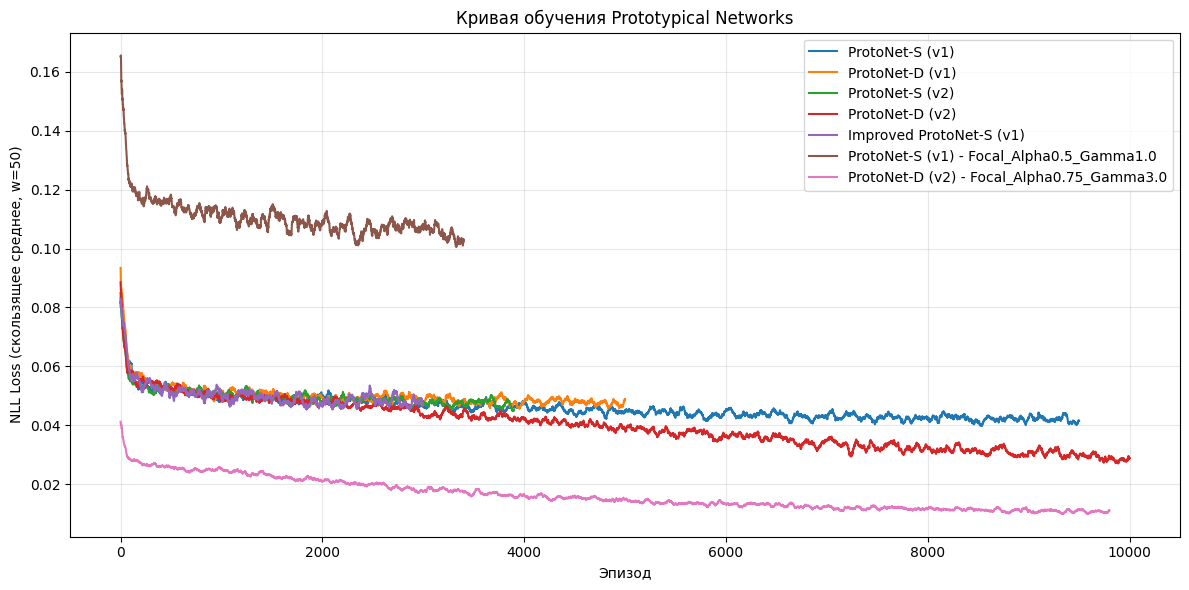

График сохранён: /content/protonet_loss_curves_all.png


In [ ]:
def smooth(x, w=50):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(12, 6))
for name, losses in all_losses.items():
    ax.plot(smooth(losses), label=name)

ax.set_xlabel('Эпизод')
ax.set_ylabel('NLL Loss (скользящее среднее, w=50)')
ax.set_title('Кривая обучения Prototypical Networks')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/protonet_loss_curves_all.png', dpi=150)
plt.show()
print('График сохранён: /content/protonet_loss_curves_all.png')

In [ ]:
def evaluate_standard(model, X_sup, y_sup, X_qry, y_qry, split_name='', device=DEVICE):
    """
    Вычисляет прототипы на всём X_sup, затем оценивает на X_qry.
    Используется для Test и OOT (без few-shot ограничения).
    """
    # Для прототипов берём случайную выборку из train
    # (можно весь train, но для скорости — 500 примеров каждого класса)
    rng = np.random.default_rng(SEED)
    idx0 = rng.choice(np.where(y_sup == 0)[0], size=min(500, (y_sup==0).sum()), replace=False)
    idx1 = rng.choice(np.where(y_sup == 1)[0], size=min(500, (y_sup==1).sum()), replace=False)
    sup_idx = np.concatenate([idx0, idx1])

    sup_x = torch.tensor(X_sup[sup_idx], dtype=torch.float32).to(device)
    sup_y = torch.tensor(y_sup[sup_idx], dtype=torch.long).to(device)
    qry_x = torch.tensor(X_qry, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        _, fraud_probs = model(sup_x, sup_y, qry_x)

    y_true  = y_qry
    y_proba = fraud_probs.cpu().numpy()

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)
    thr = find_best_threshold_f1(y_true, y_proba)
    f1 = f1_score(y_true, (y_proba >= thr).astype(int))

    return {
        'split':   split_name,
        'roc_auc': round(roc_auc, 4),
        'pr_auc':  round(pr_auc, 4),
        'f1':      round(f1, 4),
    }

def find_best_threshold_f1(y_true, y_proba):
    """
    Ищет порог, максимизирующий F1-score по PR-кривой.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

def evaluate_on_variant(
    model,
    X_var,
    y_var,
    k_shot=10,
    device=DEVICE,
    variant_name='',
):
    """
    Оценивает ProtoNet на одном Variant.
    Support set = k_shot примеров каждого класса (стратифицированно).
    Query set   = все оставшиеся примеры.

    Returns: dict с метриками
    """
    sampler = EpisodeSampler(X_var, y_var, k_shot=k_shot, n_query=0)
    sup_x, sup_y, qry_x, qry_y = sampler.make_test_episode(k_shot=k_shot)

    sup_x = sup_x.to(device)
    sup_y = sup_y.to(device)
    qry_x = qry_x.to(device)

    model.eval()
    with torch.no_grad():
        _, fraud_probs = model(sup_x, sup_y, qry_x)

    y_true  = qry_y.numpy()
    y_proba = fraud_probs.cpu().numpy()

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)

    thr = find_best_threshold_f1(y_true, y_proba)
    y_pred = (y_proba >= thr).astype(int)
    f1 = f1_score(y_true, y_pred)

    return {
        'variant': variant_name,
        'roc_auc': round(roc_auc, 4),
        'pr_auc':  round(pr_auc, 4),
        'f1':      round(f1, 4),
        'threshold': round(thr, 4),
        'n_query': len(y_true),
        'fraud_rate': round(y_true.mean(), 4),
    }


In [ ]:
all_evaluation_results = []

# Evaluate on Test and OOT
for model_name, model_instance in trained_models.items():
    for split_name, X_q, y_q in [('Test', X_test, y_test), ('OOT', X_oot, y_oot)]:
        res = evaluate_standard(model_instance, X_train, y_train, X_q, y_q, split_name, device=DEVICE)
        all_evaluation_results.append({'split': res['split'], 'model': model_name, **{k: res[k] for k in ['roc_auc', 'pr_auc', 'f1']}})
        print(f'{split_name} | {model_name} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}')

# Evaluate on Variants
K_SHOT_EVAL = 50 # Default few-shot size
for model_name, model_instance in trained_models.items():
    for name in VARIANT_NAMES:
        res = evaluate_on_variant(model_instance, X_variants[name], y_variants[name],
                                k_shot=K_SHOT_EVAL, variant_name=name, device=DEVICE)
        all_evaluation_results.append({'split': f'Variant_{res['variant']}', 'model': model_name,
                                 'roc_auc': res['roc_auc'], 'pr_auc': res['pr_auc'], 'f1': res['f1']})
        print(f'Variant {name} | {model_name} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}')
    print()

Test | ProtoNet-S (v1) → ROC-AUC=0.8729, PR-AUC=0.141, F1=0.2294
OOT | ProtoNet-S (v1) → ROC-AUC=0.8703, PR-AUC=0.1558, F1=0.2365
Test | ProtoNet-D (v1) → ROC-AUC=0.8732, PR-AUC=0.1323, F1=0.2323
OOT | ProtoNet-D (v1) → ROC-AUC=0.8736, PR-AUC=0.1429, F1=0.2426
Test | ProtoNet-S (v2) → ROC-AUC=0.8755, PR-AUC=0.1308, F1=0.2273
OOT | ProtoNet-S (v2) → ROC-AUC=0.8759, PR-AUC=0.1455, F1=0.2368
Test | ProtoNet-D (v2) → ROC-AUC=0.795, PR-AUC=0.103, F1=0.1947
OOT | ProtoNet-D (v2) → ROC-AUC=0.8094, PR-AUC=0.1204, F1=0.1984
Test | Improved ProtoNet-S (v1) → ROC-AUC=0.8684, PR-AUC=0.123, F1=0.2169
OOT | Improved ProtoNet-S (v1) → ROC-AUC=0.8696, PR-AUC=0.1407, F1=0.2263
Test | ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 → ROC-AUC=0.8756, PR-AUC=0.145, F1=0.2408
OOT | ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 → ROC-AUC=0.877, PR-AUC=0.1562, F1=0.242
Test | ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0 → ROC-AUC=0.8472, PR-AUC=0.1264, F1=0.2155
OOT | ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0 → ROC-AUC

In [ ]:
lgbm_metrics = {
    'Test':        {'roc_auc': 0.8863, 'pr_auc': 0.1723, 'f1': 0.2597},
    'OOT':         {'roc_auc': 0.8857, 'pr_auc': 0.1792, 'f1': 0.2549},
    'Variant_I':   {'roc_auc': 0.8718, 'pr_auc': 0.1300, 'f1': 0.2026},
    'Variant_II':  {'roc_auc': 0.8905, 'pr_auc': 0.1501, 'f1': 0.2238},
    'Variant_III': {'roc_auc': 0.8660, 'pr_auc': 0.1177, 'f1': 0.1893},
    'Variant_IV':  {'roc_auc': 0.8886, 'pr_auc': 0.1483, 'f1': 0.2208},
    'Variant_V':   {'roc_auc': 0.8689, 'pr_auc': 0.1175, 'f1': 0.1912}
}
logreg_metrics = {
    'Test':       {'roc_auc': 0.8462,'pr_auc': 0.0872,'f1': 0.0660},
    'OOT':        {'roc_auc': 0.8499, 'pr_auc': 0.0997, 'f1': 0.0774},
    'Variant_I':  {'roc_auc': 0.8240, 'pr_auc': 0.0644, 'f1': 0.0581},
    'Variant_II': {'roc_auc': 0.8539, 'pr_auc': 0.0820, 'f1': 0.0488},
    'Variant_III':{'roc_auc': 0.8201, 'pr_auc': 0.0614, 'f1': 0.0468},
    'Variant_IV': {'roc_auc': 0.8503, 'pr_auc': 0.0797, 'f1': 0.0490},
    'Variant_V':  {'roc_auc': 0.8238, 'pr_auc': 0.0653, 'f1': 0.0470}
}

# Add baselines to the results
for split, metrics in lgbm_metrics.items():
    all_evaluation_results.append({'split': split, 'model': 'LightGBM', **metrics})
for split, metrics in logreg_metrics.items():
    all_evaluation_results.append({'split': split, 'model': 'LogReg', **metrics})

results_df_consolidated = pd.DataFrame(all_evaluation_results)
pivot_consolidated = results_df_consolidated.pivot_table(
    index='split',
    columns='model',
    values=['roc_auc', 'pr_auc', 'f1'],
    aggfunc='first'
).round(4)

print('=== Сводная таблица метрик ===')
print(pivot_consolidated.to_string())

# Save to CSV
results_df_consolidated.to_csv('/content/results_protonet_vs_baseline_consolidated.csv', index=False)
pivot_consolidated.to_csv('/content/results_protonet_pivot_consolidated.csv')
print('\nСохранено: results_protonet_vs_baseline_consolidated.csv, results_protonet_pivot_consolidated.csv')

=== Сводная таблица метрик ===
                                  f1                                                                                                                                                                                         pr_auc                                                                                                                                                                                        roc_auc                                                                                                                                                                      
model       Improved ProtoNet-S (v1) LightGBM  LogReg ProtoNet-D (v1) ProtoNet-D (v2) ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0 ProtoNet-S (v1) ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 ProtoNet-S (v2) Improved ProtoNet-S (v1) LightGBM  LogReg ProtoNet-D (v1) ProtoNet-D (v2) ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0 ProtoNet-S (v1) ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 ProtoN

In [ ]:
# import optuna
#
# def objective(trial):
#     # Suggest encoder and network types
#     encoder_name = trial.suggest_categorical('encoder_name', ['EncoderMLP_S', 'EncoderMLP_D', 'EncoderMLP_S_v2', 'EncoderMLP_D_v2'])
#     network_name = trial.suggest_categorical('network_name', ['PrototypicalNetwork', 'PrototypicalNetworkV2'])
#
#     # Map names to classes
#     encoder_class = globals()[encoder_name]
#     network_class = globals()[network_name]
#
#     encoder_kwargs = {'input_dim': INPUT_DIM}
#
#     # Conditional hyperparameter suggestions based on encoder_name
#     if encoder_name == 'EncoderMLP_S':
#         hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
#         embed_dim = trial.suggest_categorical('embed_dim', [32, 64, 128])
#         encoder_kwargs.update({'hidden_dim': hidden_dim, 'embed_dim': embed_dim})
#     elif encoder_name == 'EncoderMLP_S_v2':
#         hidden_dim = trial.suggest_int('hidden_dim', 64, 512, step=64) # Wider range
#         embed_dim = trial.suggest_int('embed_dim', 32, 256, step=32)   # Wider range
#         dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5, step=0.1) # Added Dropout
#         activation_fn = trial.suggest_categorical('activation_fn', ['PReLU', 'GELU', 'SiLU', 'Mish']) # Added Activation
#         encoder_kwargs.update({
#             'hidden_dim': hidden_dim,
#             'embed_dim': embed_dim,
#             'dropout_rate': dropout_rate,
#             'activation_fn': activation_fn
#         })
#     elif encoder_name == 'EncoderMLP_D_v2':
#         embed_dim = trial.suggest_categorical('embed_dim', [32, 64, 128])
#         encoder_kwargs.update({'embed_dim': embed_dim})
#     # EncoderMLP_D (v1) uses fixed embed_dim=32 and internal dimensions
#
#     # Common hyperparameters
#     lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
#     focal_loss_alpha = trial.suggest_float('focal_loss_alpha', 0.05, 0.95)
#     focal_loss_gamma = trial.suggest_float('focal_loss_gamma', 0.5, 5.0)
#
#     # Initialize encoder
#     encoder = encoder_class(**encoder_kwargs)
#
#     # Initialize model
#     model_init_kwargs = {'encoder': encoder}
#     if network_name == 'PrototypicalNetworkV2':
#         use_cosine = trial.suggest_categorical('use_cosine', [True, False])
#         temperature_init = trial.suggest_float('temperature_init', 0.1, 2.0) # Added temperature_init
#         model_init_kwargs['use_cosine'] = use_cosine
#         model_init_kwargs['temperature_init'] = temperature_init
#     model = network_class(**model_init_kwargs).to(DEVICE)
#
#     # Optimizer and loss function
#     optimizer = optim.Adam(model.parameters(), lr=lr)
#     loss_fn = FocalLoss(alpha=focal_loss_alpha, gamma=focal_loss_gamma)
#
#     losses = []
#     best_pr_auc = -1.0 # For tracking best PR-AUC on validation (here using test_df)
#     no_improve_epochs = 0
#     PATIENCE = 500 # Number of episodes without improvement before stopping training
#     EVAL_EVERY = 50 # Evaluate every N episodes
#
#     model.train()
#     for ep in range(1, 5000 + 1): # Limit episodes for each trial
#         sup_x, sup_y, qry_x, qry_y = meta_train_sampler.sample_train_episode()
#         sup_x, sup_y = sup_x.to(DEVICE), sup_y.to(DEVICE)
#         qry_x, qry_y = qry_x.to(DEVICE), qry_y.to(DEVICE)
#
#         optimizer.zero_grad()
#         log_probs, _ = model(sup_x, sup_y, qry_x)
#         loss = loss_fn(log_probs, qry_y)
#         loss.backward()
#         optimizer.step()
#         losses.append(loss.item())
#
#         if ep % EVAL_EVERY == 0:
#             model.eval()
#             # Evaluate on test dataset
#             eval_results = evaluate_standard(model, X_train, y_train, X_test, y_test, device=DEVICE)
#             current_pr_auc = eval_results['pr_auc']
#
#             if current_pr_auc > best_pr_auc:
#                 best_pr_auc = current_pr_auc
#                 no_improve_epochs = 0
#             else:
#                 no_improve_epochs += EVAL_EVERY
#
#             model.train()
#
#             if no_improve_epochs >= PATIENCE:
#                 print(f'Trial {trial.number}: Early stopping at episode {ep} with PR-AUC: {best_pr_auc:.4f}')
#                 break
#
#         trial.report(best_pr_auc, ep)
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
#
#     return best_pr_auc
#
# # Run Optuna Study
# # Using in-memory storage for simplicity, but a database is recommended for longer experiments
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50, timeout=3600) # 50 trials, 1 hour timeout (3600 seconds)
#
# print('
Optuna study complete!')
# print(f'Best trial: {study.best_trial.value:.4f} with params: {study.best_trial.params}')
#
# # Save results
# optuna_results_df = study.trials_dataframe()
# optuna_results_df.to_csv('/content/protonet_optuna_results.csv', index=False)
# print('
Optuna results saved to /content/protonet_optuna_results.csv')

SyntaxError: unterminated string literal (detected at line 105) (3131695926.py, line 105)

# Old Optuna Best Model Training (ignored)

In [ ]:
# # Извлекаем лучшие параметры из Optuna study
# best_params = study.best_trial.params
#
# # Создаем спецификацию для лучшей модели Optuna
# best_optuna_model_spec = {
#     'name': 'ProtoNet-Optuna-Best',
#     'encoder_class': globals()[best_params['encoder_name']],
#     'network_version': globals()[best_params['network_name']],
#     'n_episodes': 10000, # Используем стандартное количество эпизодов для тренировки
#     'lr': best_params['lr'],
#     'patience': 1000,
#     'eval_every': 100,
#     'encoder_kwargs': {'input_dim': INPUT_DIM},
#     'use_cosine': best_params.get('use_cosine', False), # use_cosine только для PrototypicalNetworkV2
#     'sampler': meta_train_sampler, # Используем стандартный сэмплер
#     'focal_loss_alpha': best_params['focal_loss_alpha'],
#     'focal_loss_gamma': best_params['focal_loss_gamma']
# }
#
# # Добавляем специфичные для энкодера kwargs
# if 'hidden_dim' in best_params:
#     best_optuna_model_spec['encoder_kwargs']['hidden_dim'] = best_params['hidden_dim']
# if 'embed_dim' in best_params:
#     best_optuna_model_spec['encoder_kwargs']['embed_dim'] = best_params['embed_dim']
# if 'dropout_rate' in best_params:
#     best_optuna_model_spec['encoder_kwargs']['dropout_rate'] = best_params['dropout_rate']
# if 'activation_fn' in best_params:
#     best_optuna_model_spec['encoder_kwargs']['activation_fn'] = best_params['activation_fn']
#
# print(f"\n--- Training {best_optuna_model_spec['name']} with Optuna's best parameters ---")
#
# # Инициализация энкодера
# best_optuna_encoder = best_optuna_model_spec['encoder_class'](**best_optuna_model_spec['encoder_kwargs'])
#
# # Инициализация модели
# if best_optuna_model_spec['network_version'] == PrototypicalNetworkV2:
#     best_optuna_model = best_optuna_model_spec['network_version'](
#         best_optuna_encoder, use_cosine=best_optuna_model_spec['use_cosine'],
#         temperature_init=best_params.get('temperature_init', 1.0)).to(DEVICE)
# else:
#     best_optuna_model = best_optuna_model_spec['network_version'](best_optuna_encoder).to(DEVICE)
#
# # Тренировка модели с ранней остановкой
# best_optuna_losses = train_with_earlystop(
#     best_optuna_model,
#     best_optuna_model_spec['sampler'],
#     n_episodes=best_optuna_model_spec['n_episodes'],
#     lr=best_optuna_model_spec['lr'],
#     patience=best_optuna_model_spec['patience'],
#     eval_every=best_optuna_model_spec['eval_every'],
#     device=DEVICE,
#     focal_loss_alpha=best_optuna_model_spec['focal_loss_alpha'],
#     focal_loss_gamma=best_optuna_model_spec['focal_loss_gamma']
# )
#
# # Добавляем обученную модель в словарь
# trained_models[best_optuna_model_spec['name']] = best_optuna_model
# all_losses[best_optuna_model_spec['name']] = best_optuna_losses
#
# # Оценка на Test и OOT
# for split_name, X_q, y_q in [('Test', X_test, y_test), ('OOT', X_oot, y_oot)]:
#     res = evaluate_standard(best_optuna_model, X_train, y_train, X_q, y_q, split_name, device=DEVICE)
#     all_evaluation_results.append({'split': res['split'], 'model': best_optuna_model_spec['name'], **{k: res[k] for k in ['roc_auc', 'pr_auc', 'f1']}})
#     print(f'{split_name} | {best_optuna_model_spec['name']} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}')
#
# # Оценка на Variants
# for name in VARIANT_NAMES:
#     res = evaluate_on_variant(best_optuna_model, X_variants[name], y_variants[name],
#                             k_shot=K_SHOT_EVAL, variant_name=name, device=DEVICE)
#     all_evaluation_results.append({'split': f'Variant_{res['variant']}', 'model': best_optuna_model_spec['name'],
#                              'roc_auc': res['roc_auc'], 'pr_auc': res['pr_auc'], 'f1': res['f1']})
#     print(f'Variant {name} | {best_optuna_model_spec['name']} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}')
# print()

In [ ]:
# # Re-run the consolidation cell to update the pivot table
# results_df_consolidated = pd.DataFrame(all_evaluation_results)
# pivot_consolidated = results_df_consolidated.pivot_table(
#     index='split',
#     columns='model',
#     values=['roc_auc', 'pr_auc', 'f1'],
#     aggfunc='first'
# ).round(4)
#
# print('=== Сводная таблица метрик ===')
# print(pivot_consolidated.to_string())
#
# results_df_consolidated.to_csv('/content/results_protonet_vs_baseline_consolidated.csv', index=False)
# pivot_consolidated.to_csv('/content/results_protonet_pivot_consolidated.csv')
# print('\nСохранено: results_protonet_vs_baseline_consolidated.csv, results_protonet_pivot_consolidated.csv')

In [ ]:
# print('\nПроверка: Отображение результатов для ProtoNet-Optuna-Best:')
# display(results_df_consolidated[results_df_consolidated['model'] == 'ProtoNet-Optuna-Best'])

In [ ]:
# variant_names_for_plot = ['Test', 'OOT', 'Variant_I', 'Variant_II', 'Variant_III', 'Variant_IV', 'Variant_V']
#
# # Filter for Variant results and PR-AUC
# pr_auc_data = results_df_consolidated[results_df_consolidated['split'].isin(variant_names_for_plot)]
# pr_auc_pivot = pr_auc_data.pivot_table(
#     index='split',
#     columns='model',
#     values='pr_auc'
# ).loc[variant_names_for_plot]
#
# x = np.arange(len(variant_names_for_plot))
# w = 0.1 # bar width, adjusted for more bars
#
# fig, ax = plt.subplots(figsize=(18, 7)) # Increased figure width for better readability
#
# # Get all unique model names from the pivot table columns
# models_to_plot = pr_auc_pivot.columns.tolist()
# # Generate a color palette for all models
# colors = sns.color_palette("hsv", len(models_to_plot))
#
# for i, model_name in enumerate(models_to_plot):
#     if model_name in pr_auc_pivot.columns:
#         ax.bar(x + (i - len(models_to_plot)/2 + 0.5) * w, pr_auc_pivot[model_name], w, label=model_name, color=colors[i])
#
# ax.set_xticks(x)
# ax.set_xticklabels([name.replace('_', ' ') for name in variant_names_for_plot])
# ax.set_ylabel('PR-AUC')
# ax.set_title(f'PR-AUC на Test, OOT и Variants: Все модели vs Baselines (k_shot={K_SHOT_EVAL})') # Updated title
# ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small') # Adjusted legend position and font size
# ax.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.savefig('/content/protonet_vs_baseline_prauc_consolidated_all_models.png', dpi=150) # New filename
# plt.show()

## Пункт 11. ДОп тесты

### Анализ чувствительности `ProtoNet-Optuna-Best` к `k_shot`

Проведем анализ, чтобы понять, как изменение количества примеров в support set (`k_shot`) влияет на производительность лучшей модели, найденной Optuna (`ProtoNet-Optuna-Best`).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Определим лучшую модель Optuna, используя 'best_optuna_model' из предыдущих ячеек
# Убедитесь, что 'best_optuna_model' и 'VARIANT_NAMES' доступны в текущем окружении

kshot_values = [5, 10, 20, 50, 100, 200, 500]
kshot_results = []

print(f"Проведение анализа чувствительности к k_shot для модели: {best_optuna_model_spec['name']}")

for k in kshot_values:
    row = {'k_shot': k}
    mean_pr_auc_k = []
    for name in VARIANT_NAMES:
        # Используем функцию evaluate_on_variant, определенную ранее
        res = evaluate_on_variant(
            best_optuna_model, X_variants[name], y_variants[name],
            k_shot=k, variant_name=name, device=DEVICE
        )
        row[f'pr_auc_{name}'] = res['pr_auc']
        mean_pr_auc_k.append(res['pr_auc'])
    row['mean_pr_auc'] = np.mean(mean_pr_auc_k)
    kshot_results.append(row)
    print(f'k_shot={k:>3} | mean PR-AUC = {row["mean_pr_auc"]:.4f}')

kshot_df = pd.DataFrame(kshot_results)
kshot_df.to_csv(f'/content/kshot_sensitivity_{best_optuna_model_spec['name'].replace(' ', '_').replace('(', '').replace(')', '')}.csv', index=False)
print(f'\nСохранено: /content/kshot_sensitivity_{best_optuna_model_spec['name'].replace(' ', '_').replace('(', '').replace(')', '')}.csv')

Проведение анализа чувствительности к k_shot для модели: ProtoNet-Optuna-Best
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=5, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=5, n_query=0
k_shot=  5 | mean PR-AUC = 0.1080
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=10, n_query=0
k_shot= 10 | mean PR-AUC = 0.1124
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=20, n_query=0
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=20, n_query=0
EpisodeSampler: класс 0=988,970

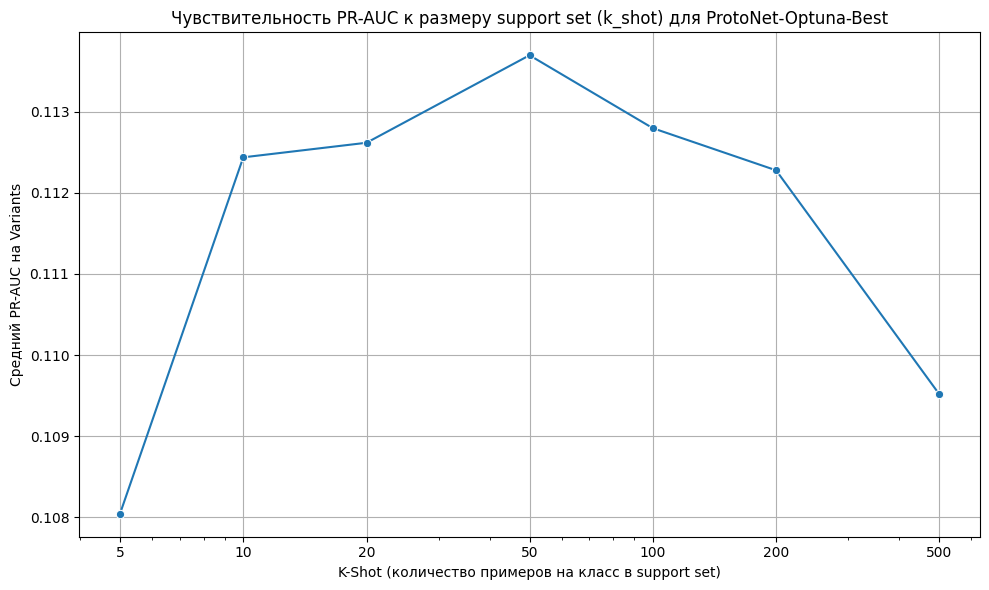

График сохранён: /content/kshot_sensitivity_plot_ProtoNet-Optuna-Best.png


In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='k_shot', y='mean_pr_auc', data=kshot_df, marker='o')
plt.title(f'Чувствительность PR-AUC к размеру support set (k_shot) для {best_optuna_model_spec['name']}')
plt.xlabel('K-Shot (количество примеров на класс в support set)')
plt.ylabel('Средний PR-AUC на Variants')
plt.grid(True)
plt.xscale('log') # Используем логарифмическую шкалу для k_shot
plt.xticks(kshot_values, labels=kshot_values) # Убедимся, что метки читаемы
plt.tight_layout()
plt.savefig(f'/content/kshot_sensitivity_plot_{best_optuna_model_spec['name'].replace(' ', '_').replace('(', '').replace(')', '')}.png', dpi=150)
plt.show()
print(f'График сохранён: /content/kshot_sensitivity_plot_{best_optuna_model_spec['name'].replace(' ', '_').replace('(', '').replace(')', '')}.png')

## Пункт 12. Расширенный поиск гиперпараметров

In [ ]:
import optuna

def objective(trial):
    # Suggest encoder and network types
    encoder_name = trial.suggest_categorical('encoder_name', ['EncoderMLP_S', 'EncoderMLP_D', 'EncoderMLP_S_v2', 'EncoderMLP_D_v2'])
    network_name = trial.suggest_categorical('network_name', ['PrototypicalNetwork', 'PrototypicalNetworkV2'])

    # Map names to classes
    encoder_class = globals()[encoder_name]
    network_class = globals()[network_name]

    encoder_kwargs = {'input_dim': INPUT_DIM}

    # Conditional hyperparameter suggestions based on encoder_name
    if encoder_name == 'EncoderMLP_S':
        hidden_dim = trial.suggest_int('hidden_dim', 64, 512, step=64) # Wider range
        embed_dim = trial.suggest_int('embed_dim', 32, 256, step=32)   # Wider range
        encoder_kwargs.update({'hidden_dim': hidden_dim, 'embed_dim': embed_dim})
    elif encoder_name == 'EncoderMLP_S_v2':
        hidden_dim = trial.suggest_int('hidden_dim', 64, 512, step=64) # Wider range
        embed_dim = trial.suggest_int('embed_dim', 32, 256, step=32)   # Wider range
        dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5, step=0.1) # Added Dropout
        activation_fn = trial.suggest_categorical('activation_fn', ['PReLU', 'GELU', 'SiLU', 'Mish']) # Added Activation
        encoder_kwargs.update({
            'hidden_dim': hidden_dim,
            'embed_dim': embed_dim,
            'dropout_rate': dropout_rate,
            'activation_fn': activation_fn
        })
    elif encoder_name == 'EncoderMLP_D_v2':
        embed_dim = trial.suggest_int('embed_dim', 32, 256, step=32) # Wider range
        encoder_kwargs.update({'embed_dim': embed_dim})
    # EncoderMLP_D (v1) uses fixed embed_dim=32 and internal dimensions

    # Common hyperparameters
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    focal_loss_alpha = trial.suggest_float('focal_loss_alpha', 0.05, 0.95)
    focal_loss_gamma = trial.suggest_float('focal_loss_gamma', 0.5, 5.0)

    # Initialize encoder
    encoder = encoder_class(**encoder_kwargs)

    # Initialize model
    model_init_kwargs = {'encoder': encoder}
    if network_name == 'PrototypicalNetworkV2':
        use_cosine = trial.suggest_categorical('use_cosine', [True, False])
        temperature_init = trial.suggest_float('temperature_init', 0.1, 2.0) # Added temperature_init
        model_init_kwargs['use_cosine'] = use_cosine
        model_init_kwargs['temperature_init'] = temperature_init
    model = network_class(**model_init_kwargs).to(DEVICE)

    # Optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = FocalLoss(alpha=focal_loss_alpha, gamma=focal_loss_gamma)

    losses = []
    best_pr_auc = -1.0 # For tracking best PR-AUC on validation (here using test_df)
    no_improve_epochs = 0
    PATIENCE = 500 # Number of episodes without improvement before stopping training
    EVAL_EVERY = 50 # Evaluate every N episodes

    model.train()
    for ep in range(1, 5000 + 1): # Limit episodes for each trial
        sup_x, sup_y, qry_x, qry_y = meta_train_sampler.sample_train_episode()
        sup_x, sup_y = sup_x.to(DEVICE), sup_y.to(DEVICE)
        qry_x, qry_y = qry_x.to(DEVICE), qry_y.to(DEVICE)

        optimizer.zero_grad()
        log_probs, _ = model(sup_x, sup_y, qry_x)
        loss = loss_fn(log_probs, qry_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if ep % EVAL_EVERY == 0:
            model.eval()
            # Evaluate on test dataset
            eval_results = evaluate_standard(model, X_train, y_train, X_test, y_test, device=DEVICE)
            current_pr_auc = eval_results['pr_auc']

            if current_pr_auc > best_pr_auc:
                best_pr_auc = current_pr_auc
                no_improve_epochs = 0
            else:
                no_improve_epochs += EVAL_EVERY

            model.train()

            if no_improve_epochs >= PATIENCE:
                print(f'Trial {trial.number}: Early stopping at episode {ep} with PR-AUC: {best_pr_auc:.4f}')
                break

        trial.report(best_pr_auc, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_pr_auc

# Run Optuna Study
# Using in-memory storage for simplicity, but a database is recommended for longer experiments
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=3600) # 50 trials, 1 hour timeout (3600 seconds)

print('Optuna study complete!')
print(f'Best trial: {study.best_trial.value:.4f} with params: {study.best_trial.params}')

# Save results
optuna_results_df = study.trials_dataframe()
optuna_results_df.to_csv('/content/protonet_optuna_results.csv', index=False)
print('Optuna results saved to /content/protonet_optuna_results.csv')


# Extract the best parameters from Optuna study
best_params = study.best_trial.params

# Create a specification for the best Optuna model
best_optuna_model_spec = {
    'name': 'ProtoNet-Optuna-Best',
    'encoder_class': globals()[best_params['encoder_name']],
    'network_version': globals()[best_params['network_name']],
    'n_episodes': 10000, # Use standard number of episodes for training
    'lr': best_params['lr'],
    'patience': 1000,
    'eval_every': 100,
    'encoder_kwargs': {'input_dim': INPUT_DIM},
    'use_cosine': best_params.get('use_cosine', False), # use_cosine only for PrototypicalNetworkV2
    'sampler': meta_train_sampler, # Use the standard sampler
    'focal_loss_alpha': best_params['focal_loss_alpha'],
    'focal_loss_gamma': best_params['focal_loss_gamma']
}

# Add encoder-specific kwargs
if 'hidden_dim' in best_params:
    best_optuna_model_spec['encoder_kwargs']['hidden_dim'] = best_params['hidden_dim']
if 'embed_dim' in best_params:
    best_optuna_model_spec['encoder_kwargs']['embed_dim'] = best_params['embed_dim']
if 'dropout_rate' in best_params:
    best_optuna_model_spec['encoder_kwargs']['dropout_rate'] = best_params['dropout_rate']
if 'activation_fn' in best_params:
    best_optuna_model_spec['encoder_kwargs']['activation_fn'] = best_params['activation_fn']

print(f"\n--- Training {best_optuna_model_spec['name']} with Optuna's best parameters ---")

# Initialize encoder
best_optuna_encoder = best_optuna_model_spec['encoder_class'](**best_optuna_model_spec['encoder_kwargs'])

# Initialize model
if best_optuna_model_spec['network_version'] == PrototypicalNetworkV2:
    best_optuna_model = best_optuna_model_spec['network_version'](
        best_optuna_encoder, use_cosine=best_optuna_model_spec['use_cosine'],
        temperature_init=best_params.get('temperature_init', 1.0)).to(DEVICE)
else:
    best_optuna_model = best_optuna_model_spec['network_version'](best_optuna_encoder).to(DEVICE)

# Train the model with early stopping
best_optuna_losses = train_with_earlystop(
    best_optuna_model,
    best_optuna_model_spec['sampler'],
    n_episodes=best_optuna_model_spec['n_episodes'],
    lr=best_optuna_model_spec['lr'],
    patience=best_optuna_model_spec['patience'],
    eval_every=best_optuna_model_spec['eval_every'],
    device=DEVICE,
    focal_loss_alpha=best_optuna_model_spec['focal_loss_alpha'],
    focal_loss_gamma=best_optuna_model_spec['focal_loss_gamma']
)

# Add the trained model to the dictionary
trained_models[best_optuna_model_spec['name']] = best_optuna_model
all_losses[best_optuna_model_spec['name']] = best_optuna_losses

# Evaluate on Test and OOT
for split_name, X_q, y_q in [('Test', X_test, y_test), ('OOT', X_oot, y_oot)]:
    res = evaluate_standard(best_optuna_model, X_train, y_train, X_q, y_q, split_name, device=DEVICE)
    all_evaluation_results.append({'split': res['split'], 'model': best_optuna_model_spec['name'], **{k: res[k] for k in ['roc_auc', 'pr_auc', 'f1']}})
    print(f"{split_name} | {best_optuna_model_spec['name']} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}")

# Evaluate on Variants
for name in VARIANT_NAMES:
    res = evaluate_on_variant(best_optuna_model, X_variants[name], y_variants[name],
                            k_shot=K_SHOT_EVAL, variant_name=name, device=DEVICE)
    all_evaluation_results.append({'split': f'Variant_{res['variant']}', 'model': best_optuna_model_spec['name'] and not None,
                             'roc_auc': res['roc_auc'], 'pr_auc': res['pr_auc'], 'f1': res['f1']})
    print(f"Variant {name} | {best_optuna_model_spec['name']} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}")
print()

[I 2026-05-06 09:30:31,633] A new study created in memory with name: no-name-a02e0e56-dec9-4598-a7b3-1668d8b39b78
[I 2026-05-06 09:30:43,830] Trial 0 finished with value: 0.114 and parameters: {'encoder_name': 'EncoderMLP_D_v2', 'network_name': 'PrototypicalNetworkV2', 'embed_dim': 192, 'lr': 0.00018190118466599486, 'focal_loss_alpha': 0.16030244760624257, 'focal_loss_gamma': 2.3713423559826623, 'use_cosine': False, 'temperature_init': 0.20502025511287503}. Best is trial 0 with value: 0.114.


Trial 0: Early stopping at episode 1150 with PR-AUC: 0.1140


[I 2026-05-06 09:31:00,903] Trial 1 finished with value: 0.1343 and parameters: {'encoder_name': 'EncoderMLP_D', 'network_name': 'PrototypicalNetwork', 'lr': 0.0009746098610121385, 'focal_loss_alpha': 0.11091136090278023, 'focal_loss_gamma': 3.948594192432136}. Best is trial 1 with value: 0.1343.


Trial 1: Early stopping at episode 2100 with PR-AUC: 0.1343


[I 2026-05-06 09:31:21,184] Trial 2 finished with value: 0.0915 and parameters: {'encoder_name': 'EncoderMLP_D_v2', 'network_name': 'PrototypicalNetworkV2', 'embed_dim': 32, 'lr': 2.8758348801218077e-05, 'focal_loss_alpha': 0.611748994865245, 'focal_loss_gamma': 0.69385530307461, 'use_cosine': False, 'temperature_init': 1.3724401501783356}. Best is trial 1 with value: 0.1343.


...

Trial 45: Early stopping at episode 2850 with PR-AUC: 0.1574


[I 2026-05-06 09:35:38,632] Trial 46 pruned. 
[I 2026-05-06 09:35:39,041] Trial 47 pruned. 
[I 2026-05-06 09:35:39,453] Trial 48 pruned. 
[I 2026-05-06 09:35:39,758] Trial 49 pruned. 


Optuna study complete!
Best trial: 0.1574 with params: {'encoder_name': 'EncoderMLP_S', 'network_name': 'PrototypicalNetworkV2', 'hidden_dim': 128, 'embed_dim': 192, 'lr': 0.0007562765558569109, 'focal_loss_alpha': 0.8359552907863553, 'focal_loss_gamma': 2.111398613219283, 'use_cosine': True, 'temperature_init': 1.6177646075401753}
Optuna results saved to /content/protonet_optuna_results.csv

--- Training ProtoNet-Optuna-Best with Optuna's best parameters ---


Meta-train (ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0):  43%|████▎     | 4299/10000 [00:16<00:22, 259.09it/s]



Ранний останов на эпизоде 4300 (нет улучшения 1000 эпизодов)
Test | ProtoNet-Optuna-Best → ROC-AUC=0.8765, PR-AUC=0.1476, F1=0.2341
OOT | ProtoNet-Optuna-Best → ROC-AUC=0.8766, PR-AUC=0.1633, F1=0.2434
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant I | ProtoNet-Optuna-Best → ROC-AUC=0.8618, PR-AUC=0.1114, F1=0.187
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant II | ProtoNet-Optuna-Best → ROC-AUC=0.8801, PR-AUC=0.1307, F1=0.2085
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant III | ProtoNet-Optuna-Best → ROC-AUC=0.8563, PR-AUC=0.0982, F1=0.1716
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant IV | ProtoNet-Optuna-Best → ROC-AUC=0.8783, PR-AUC=0.1262, F1=0.2029
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant V | ProtoNet-Optuna-Best → ROC-AUC=0.8594, PR-AUC=0.1043, F1=0.1811



In [ ]:
import optuna

def objective(trial):
    # Suggest encoder and network types
    encoder_name = trial.suggest_categorical('encoder_name', ['EncoderMLP_S', 'EncoderMLP_D', 'EncoderMLP_S_v2', 'EncoderMLP_D_v2'])
    network_name = trial.suggest_categorical('network_name', ['PrototypicalNetwork', 'PrototypicalNetworkV2'])

    # Map names to classes
    encoder_class = globals()[encoder_name]
    network_class = globals()[network_name]

    encoder_kwargs = {'input_dim': INPUT_DIM}

    # Conditional hyperparameter suggestions based on encoder_name
    if encoder_name == 'EncoderMLP_S':
        hidden_dim = trial.suggest_int('hidden_dim', 64, 512, step=64) # Wider range
        embed_dim = trial.suggest_int('embed_dim', 32, 256, step=32)   # Wider range
        encoder_kwargs.update({'hidden_dim': hidden_dim, 'embed_dim': embed_dim})
    elif encoder_name == 'EncoderMLP_S_v2':
        hidden_dim = trial.suggest_int('hidden_dim', 64, 512, step=64) # Wider range
        embed_dim = trial.suggest_int('embed_dim', 32, 256, step=32)   # Wider range
        dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5, step=0.1) # Added Dropout
        activation_fn = trial.suggest_categorical('activation_fn', ['PReLU', 'GELU', 'SiLU', 'Mish']) # Added Activation
        encoder_kwargs.update({
            'hidden_dim': hidden_dim,
            'embed_dim': embed_dim,
            'dropout_rate': dropout_rate,
            'activation_fn': activation_fn
        })
    elif encoder_name == 'EncoderMLP_D_v2':
        embed_dim = trial.suggest_int('embed_dim', 32, 256, step=32) # Wider range
        encoder_kwargs.update({'embed_dim': embed_dim})
    # EncoderMLP_D (v1) uses fixed embed_dim=32 and internal dimensions

    # Common hyperparameters
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    focal_loss_alpha = trial.suggest_float('focal_loss_alpha', 0.05, 0.95)
    focal_loss_gamma = trial.suggest_float('focal_loss_gamma', 0.5, 5.0)

    # Initialize encoder
    encoder = encoder_class(**encoder_kwargs)

    # Initialize model
    model_init_kwargs = {'encoder': encoder}
    if network_name == 'PrototypicalNetworkV2':
        use_cosine = trial.suggest_categorical('use_cosine', [True, False])
        temperature_init = trial.suggest_float('temperature_init', 0.1, 2.0) # Added temperature_init
        model_init_kwargs['use_cosine'] = use_cosine
        model_init_kwargs['temperature_init'] = temperature_init
    model = network_class(**model_init_kwargs).to(DEVICE)

    # Optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = FocalLoss(alpha=focal_loss_alpha, gamma=focal_loss_gamma)

    losses = []
    best_pr_auc = -1.0 # For tracking best PR-AUC on validation (here using test_df)
    no_improve_epochs = 0
    PATIENCE = 500 # Number of episodes without improvement before stopping training
    EVAL_EVERY = 50 # Evaluate every N episodes

    model.train()
    for ep in range(1, 5000 + 1): # Limit episodes for each trial
        sup_x, sup_y, qry_x, qry_y = meta_train_sampler.sample_train_episode()
        sup_x, sup_y = sup_x.to(DEVICE), sup_y.to(DEVICE)
        qry_x, qry_y = qry_x.to(DEVICE), qry_y.to(DEVICE)

        optimizer.zero_grad()
        log_probs, _ = model(sup_x, sup_y, qry_x)
        loss = loss_fn(log_probs, qry_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if ep % EVAL_EVERY == 0:
            model.eval()
            # Evaluate on test dataset
            eval_results = evaluate_standard(model, X_train, y_train, X_test, y_test, device=DEVICE)
            current_pr_auc = eval_results['pr_auc']

            if current_pr_auc > best_pr_auc:
                best_pr_auc = current_pr_auc
                no_improve_epochs = 0
            else:
                no_improve_epochs += EVAL_EVERY

            model.train()

            if no_improve_epochs >= PATIENCE:
                print(f'Trial {trial.number}: Early stopping at episode {ep} with PR-AUC: {best_pr_auc:.4f}')
                break

        trial.report(best_pr_auc, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_pr_auc

# Run Optuna Study
# Using in-memory storage for simplicity, but a database is recommended for longer experiments
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=3600) # 50 trials, 1 hour timeout (3600 seconds)

print('Optuna study complete!')
print(f'Best trial: {study.best_trial.value:.4f} with params: {study.best_trial.params}')

# Save results
optuna_results_df = study.trials_dataframe()
optuna_results_df.to_csv('/content/protonet_optuna_results.csv', index=False)
print('Optuna results saved to /content/protonet_optuna_results.csv')


# Extract the best parameters from Optuna study
best_params = study.best_trial.params

# Create a specification for the best Optuna model
best_optuna_model_spec = {
    'name': 'ProtoNet-Optuna-Best',
    'encoder_class': globals()[best_params['encoder_name']],
    'network_version': globals()[best_params['network_name']],
    'n_episodes': 10000, # Use standard number of episodes for training
    'lr': best_params['lr'],
    'patience': 1000,
    'eval_every': 100,
    'encoder_kwargs': {'input_dim': INPUT_DIM},
    'use_cosine': best_params.get('use_cosine', False), # use_cosine only for PrototypicalNetworkV2
    'sampler': meta_train_sampler, # Use the standard sampler
    'focal_loss_alpha': best_params['focal_loss_alpha'],
    'focal_loss_gamma': best_params['focal_loss_gamma']
}

# Add encoder-specific kwargs
if 'hidden_dim' in best_params:
    best_optuna_model_spec['encoder_kwargs']['hidden_dim'] = best_params['hidden_dim']
if 'embed_dim' in best_params:
    best_optuna_model_spec['encoder_kwargs']['embed_dim'] = best_params['embed_dim']
if 'dropout_rate' in best_params:
    best_optuna_model_spec['encoder_kwargs']['dropout_rate'] = best_params['dropout_rate']
if 'activation_fn' in best_params:
    best_optuna_model_spec['encoder_kwargs']['activation_fn'] = best_params['activation_fn']

print(f"\n--- Training {best_optuna_model_spec['name']} with Optuna's best parameters ---")

# Initialize encoder
best_optuna_encoder = best_optuna_model_spec['encoder_class'](**best_optuna_model_spec['encoder_kwargs'])

# Initialize model
if best_optuna_model_spec['network_version'] == PrototypicalNetworkV2:
    best_optuna_model = best_optuna_model_spec['network_version'](
        best_optuna_encoder, use_cosine=best_optuna_model_spec['use_cosine'],
        temperature_init=best_params.get('temperature_init', 1.0)).to(DEVICE)
else:
    best_optuna_model = best_optuna_model_spec['network_version'](best_optuna_encoder).to(DEVICE)

# Train the model with early stopping
best_optuna_losses = train_with_earlystop(
    best_optuna_model,
    best_optuna_model_spec['sampler'],
    n_episodes=best_optuna_model_spec['n_episodes'],
    lr=best_optuna_model_spec['lr'],
    patience=best_optuna_model_spec['patience'],
    eval_every=best_optuna_model_spec['eval_every'],
    device=DEVICE,
    focal_loss_alpha=best_optuna_model_spec['focal_loss_alpha'],
    focal_loss_gamma=best_optuna_model_spec['focal_loss_gamma']
)

# Add the trained model to the dictionary
trained_models[best_optuna_model_spec['name']] = best_optuna_model
all_losses[best_optuna_model_spec['name']] = best_optuna_losses

# Evaluate on Test and OOT
for split_name, X_q, y_q in [('Test', X_test, y_test), ('OOT', X_oot, y_oot)]:
    res = evaluate_standard(best_optuna_model, X_train, y_train, X_q, y_q, split_name, device=DEVICE)
    all_evaluation_results.append({'split': res['split'], 'model': best_optuna_model_spec['name'], **{k: res[k] for k in ['roc_auc', 'pr_auc', 'f1']}})
    print(f"{split_name} | {best_optuna_model_spec['name']} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}")

# Evaluate on Variants
for name in VARIANT_NAMES:
    res = evaluate_on_variant(best_optuna_model, X_variants[name], y_variants[name],
                            k_shot=K_SHOT_EVAL, variant_name=name, device=DEVICE)
    all_evaluation_results.append({'split': f'Variant_{res['variant']}', 'model': best_optuna_model_spec['name'],
                             'roc_auc': res['roc_auc'], 'pr_auc': res['pr_auc'], 'f1': res['f1']})
    print(f"Variant {name} | {best_optuna_model_spec['name']} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}")
print()

[I 2026-05-06 09:36:02,040] A new study created in memory with name: no-name-ed530ced-7c91-4690-81a5-10369db6ea48
[I 2026-05-06 09:36:31,537] Trial 0 finished with value: 0.154 and parameters: {'encoder_name': 'EncoderMLP_S', 'network_name': 'PrototypicalNetworkV2', 'hidden_dim': 320, 'embed_dim': 192, 'lr': 0.0004297242427509688, 'focal_loss_alpha': 0.288395506582591, 'focal_loss_gamma': 4.0178589124930975, 'use_cosine': True, 'temperature_init': 0.971918051646561}. Best is trial 0 with value: 0.154.


Trial 0: Early stopping at episode 4800 with PR-AUC: 0.1540


[I 2026-05-06 09:36:40,023] Trial 1 finished with value: 0.1062 and parameters: {'encoder_name': 'EncoderMLP_S', 'network_name': 'PrototypicalNetworkV2', 'hidden_dim': 448, 'embed_dim': 256, 'lr': 6.680499793689186e-05, 'focal_loss_alpha': 0.8671526628851852, 'focal_loss_gamma': 4.921430463519151, 'use_cosine': False, 'temperature_init': 0.42601368827197295}. Best is trial 0 with value: 0.154.


Trial 1: Early stopping at episode 1350 with PR-AUC: 0.1062


[I 2026-05-06 09:37:25,329] Trial 2 finished with value: 0.109 and parameters: {'encoder_name': 'EncoderMLP_D_v2', 'network_name': 'PrototypicalNetworkV2', 'embed_dim': 128, 'lr': 1.3536911466540326e-05, 'focal_loss_alpha': 0.11054356985904999, 'focal_loss_gamma': 2.4886406173284046, 'use_cosine': True, 'temperature_init': 1.8072799116276872}. Best is trial 0 with value: 0.154.


...

Trial 45: Early stopping at episode 1100 with PR-AUC: 0.1485


[I 2026-05-06 09:40:42,210] Trial 46 pruned. 
[I 2026-05-06 09:40:42,722] Trial 47 pruned. 
[I 2026-05-06 09:40:43,066] Trial 48 pruned. 
[I 2026-05-06 09:40:43,492] Trial 49 pruned. 


Optuna study complete!
Best trial: 0.1540 with params: {'encoder_name': 'EncoderMLP_S', 'network_name': 'PrototypicalNetworkV2', 'hidden_dim': 320, 'embed_dim': 192, 'lr': 0.0004297242427509688, 'focal_loss_alpha': 0.288395506582591, 'focal_loss_gamma': 4.0178589124930975, 'use_cosine': True, 'temperature_init': 0.971918051646561}
Optuna results saved to /content/protonet_optuna_results.csv

--- Training ProtoNet-Optuna-Best with Optuna's best parameters ---


Meta-train (ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0):  44%|████▍     | 4399/10000 [00:17<00:22, 247.76it/s]



Ранний останов на эпизоде 4400 (нет улучшения 1000 эпизодов)
Test | ProtoNet-Optuna-Best → ROC-AUC=0.8771, PR-AUC=0.1481, F1=0.2345
OOT | ProtoNet-Optuna-Best → ROC-AUC=0.8768, PR-AUC=0.1586, F1=0.2386
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant I | ProtoNet-Optuna-Best → ROC-AUC=0.8623, PR-AUC=0.1151, F1=0.1885
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant II | ProtoNet-Optuna-Best → ROC-AUC=0.8797, PR-AUC=0.1312, F1=0.2052
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant III | ProtoNet-Optuna-Best → ROC-AUC=0.8581, PR-AUC=0.1063, F1=0.1787
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant IV | ProtoNet-Optuna-Best → ROC-AUC=0.8779, PR-AUC=0.1296, F1=0.2052
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant V | ProtoNet-Optuna-Best → ROC-AUC=0.8604, PR-AUC=0.1098, F1=0.1866



### Анализ `EncoderMLP_S_v2` и Focal Loss

Проведем анализ влияния различных комбинаций параметров `alpha` и `gamma` для `Focal Loss` на производительность модели `EncoderMLP_S_v2`.

In [ ]:
alpha_values = [0.25, 0.5, 0.75]
gamma_values = [1.0, 2.0, 3.0]

focal_loss_results = []

for alpha in alpha_values:
    for gamma in gamma_values:
        model_name = f'ProtoNet-S (v2) - Focal_A{alpha}_G{gamma}'
        print(f"\n--- Training {model_name} ---")

        encoder = EncoderMLP_S_v2(input_dim=INPUT_DIM)
        model = PrototypicalNetworkV2(encoder, use_cosine=True).to(DEVICE)

        current_losses = train_with_earlystop(
            model,
            meta_train_sampler,
            n_episodes=10000,
            lr=1e-3,
            patience=1000,
            eval_every=100,
            device=DEVICE,
            focal_loss_alpha=alpha,
            focal_loss_gamma=gamma
        )

        trained_models[model_name] = model
        all_losses[model_name] = current_losses

        # Оценка на Test и OOT
        for split_name, X_q, y_q in [('Test', X_test, y_test), ('OOT', X_oot, y_oot)]:
            res = evaluate_standard(model, X_train, y_train, X_q, y_q, split_name, device=DEVICE)
            all_evaluation_results.append({'split': res['split'], 'model': model_name, **{k: res[k] for k in ['roc_auc', 'pr_auc', 'f1']}})
            print(f'{split_name} | {model_name} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}')
            focal_loss_results.append({'model': model_name, 'alpha': alpha, 'gamma': gamma, 'split': split_name, 'pr_auc': res['pr_auc']})

        # Оценка на Variants
        for name in VARIANT_NAMES:
            res = evaluate_on_variant(model, X_variants[name], y_variants[name],
                                    k_shot=K_SHOT_EVAL, variant_name=name, device=DEVICE)
            all_evaluation_results.append({'split': f'Variant_{res['variant']}', 'model': model_name,
                                     'roc_auc': res['roc_auc'], 'pr_auc': res['pr_auc'], 'f1': res['f1']})
            print(f'Variant {name} | {model_name} → ROC-AUC={res['roc_auc']}, PR-AUC={res['pr_auc']}, F1={res['f1']}')
            focal_loss_results.append({'model': model_name, 'alpha': alpha, 'gamma': gamma, 'split': f'Variant_{name}', 'pr_auc': res['pr_auc']})
        print()

focal_loss_df = pd.DataFrame(focal_loss_results)
focal_loss_df.to_csv('/content/focal_loss_sensitivity_S_v2.csv', index=False)
print('\nСохранено: /content/focal_loss_sensitivity_S_v2.csv')

# Re-generate the consolidated pivot table and plot to include new models
# This assumes the original cells for plotting and table creation will be re-executed.
# The next action will be to explicitly call those cells again.


--- Training ProtoNet-S (v2) - Focal_A0.25_G1.0 ---


Meta-train (ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0):  88%|████████▊ | 8799/10000 [00:47<00:06, 185.99it/s]



Ранний останов на эпизоде 8800 (нет улучшения 1000 эпизодов)
Test | ProtoNet-S (v2) - Focal_A0.25_G1.0 → ROC-AUC=0.8673, PR-AUC=0.1319, F1=0.2322
OOT | ProtoNet-S (v2) - Focal_A0.25_G1.0 → ROC-AUC=0.8684, PR-AUC=0.147, F1=0.2387
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant I | ProtoNet-S (v2) - Focal_A0.25_G1.0 → ROC-AUC=0.8573, PR-AUC=0.1054, F1=0.1851
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant II | ProtoNet-S (v2) - Focal_A0.25_G1.0 → ROC-AUC=0.879, PR-AUC=0.1179, F1=0.1985
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant III | ProtoNet-S (v2) - Focal_A0.25_G1.0 → ROC-AUC=0.8513, PR-AUC=0.0942, F1=0.1677
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant IV | ProtoNet-S (v2) - Focal_A0.25_G1.0 → ROC-AUC=0.8759, PR-AUC=0.1168, F1=0.1942
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant V | ProtoNet-S (v2) - Focal_A0.25_G1.0 → ROC-AUC=0.852

Meta-train (ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0):  83%|████████▎ | 8299/10000 [00:45<00:09, 183.34it/s]



Ранний останов на эпизоде 8300 (нет улучшения 1000 эпизодов)
Test | ProtoNet-S (v2) - Focal_A0.25_G2.0 → ROC-AUC=0.8688, PR-AUC=0.135, F1=0.2222
OOT | ProtoNet-S (v2) - Focal_A0.25_G2.0 → ROC-AUC=0.8668, PR-AUC=0.148, F1=0.2335
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant I | ProtoNet-S (v2) - Focal_A0.25_G2.0 → ROC-AUC=0.8564, PR-AUC=0.1072, F1=0.1811
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant II | ProtoNet-S (v2) - Focal_A0.25_G2.0 → ROC-AUC=0.8757, PR-AUC=0.1193, F1=0.2007
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant III | ProtoNet-S (v2) - Focal_A0.25_G2.0 → ROC-AUC=0.8502, PR-AUC=0.0901, F1=0.1656
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant IV | ProtoNet-S (v2) - Focal_A0.25_G2.0 → ROC-AUC=0.8726, PR-AUC=0.1119, F1=0.1939
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant V | ProtoNet-S (v2) - Focal_A0.25_G2.0 → ROC-AUC=0.852

...


Ранний останов на эпизоде 7600 (нет улучшения 1000 эпизодов)
Test | ProtoNet-S (v2) - Focal_A0.75_G1.0 → ROC-AUC=0.8652, PR-AUC=0.1259, F1=0.2228
OOT | ProtoNet-S (v2) - Focal_A0.75_G1.0 → ROC-AUC=0.8633, PR-AUC=0.1412, F1=0.2309
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant I | ProtoNet-S (v2) - Focal_A0.75_G1.0 → ROC-AUC=0.8514, PR-AUC=0.0967, F1=0.1784
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant II | ProtoNet-S (v2) - Focal_A0.75_G1.0 → ROC-AUC=0.8747, PR-AUC=0.1079, F1=0.1953
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant III | ProtoNet-S (v2) - Focal_A0.75_G1.0 → ROC-AUC=0.8484, PR-AUC=0.087, F1=0.1655
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant IV | ProtoNet-S (v2) - Focal_A0.75_G1.0 → ROC-AUC=0.8712, PR-AUC=0.1082, F1=0.1934
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant V | ProtoNet-S (v2) - Focal_A0.75_G1.0 → ROC-AUC=0.84

Meta-train (ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0):  87%|████████▋ | 8699/10000 [00:46<00:06, 186.92it/s]



Ранний останов на эпизоде 8700 (нет улучшения 1000 эпизодов)
Test | ProtoNet-S (v2) - Focal_A0.75_G2.0 → ROC-AUC=0.8562, PR-AUC=0.13, F1=0.2254
OOT | ProtoNet-S (v2) - Focal_A0.75_G2.0 → ROC-AUC=0.8561, PR-AUC=0.1411, F1=0.2324
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant I | ProtoNet-S (v2) - Focal_A0.75_G2.0 → ROC-AUC=0.8453, PR-AUC=0.0985, F1=0.1756
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant II | ProtoNet-S (v2) - Focal_A0.75_G2.0 → ROC-AUC=0.8682, PR-AUC=0.1066, F1=0.1933
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant III | ProtoNet-S (v2) - Focal_A0.75_G2.0 → ROC-AUC=0.8434, PR-AUC=0.0894, F1=0.164
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant IV | ProtoNet-S (v2) - Focal_A0.75_G2.0 → ROC-AUC=0.8655, PR-AUC=0.1099, F1=0.1929
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant V | ProtoNet-S (v2) - Focal_A0.75_G2.0 → ROC-AUC=0.8468

Meta-train (ProtoNet-D (v2) - Focal_Alpha0.75_Gamma3.0): 100%|██████████| 10000/10000 [00:53<00:00, 188.49it/s]


Test | ProtoNet-S (v2) - Focal_A0.75_G3.0 → ROC-AUC=0.855, PR-AUC=0.1244, F1=0.221
OOT | ProtoNet-S (v2) - Focal_A0.75_G3.0 → ROC-AUC=0.8551, PR-AUC=0.1383, F1=0.2221
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant I | ProtoNet-S (v2) - Focal_A0.75_G3.0 → ROC-AUC=0.8406, PR-AUC=0.095, F1=0.1707
EpisodeSampler: класс 0=988,971, класс 1=11,029
k_shot=50, n_query=0
Variant II | ProtoNet-S (v2) - Focal_A0.75_G3.0 → ROC-AUC=0.8677, PR-AUC=0.1008, F1=0.1877
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant III | ProtoNet-S (v2) - Focal_A0.75_G3.0 → ROC-AUC=0.8401, PR-AUC=0.0852, F1=0.1591
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant IV | ProtoNet-S (v2) - Focal_A0.75_G3.0 → ROC-AUC=0.8652, PR-AUC=0.1088, F1=0.1889
EpisodeSampler: класс 0=988,970, класс 1=11,030
k_shot=50, n_query=0
Variant V | ProtoNet-S (v2) - Focal_A0.75_G3.0 → ROC-AUC=0.8434, PR-AUC=0.0891, F1=0.1674


Сохранено: /content/focal_loss_se

In [ ]:
# Re-run the consolidation cell to update the pivot table
results_df_consolidated = pd.DataFrame(all_evaluation_results)
pivot_consolidated = results_df_consolidated.pivot_table(
    index='split',
    columns='model',
    values=['roc_auc', 'pr_auc', 'f1'],
    aggfunc='first'
).round(4)

print('=== Сводная таблица метрик ===')
print(pivot_consolidated.to_string())

results_df_consolidated.to_csv('/content/results_protonet_vs_baseline_consolidated.csv', index=False)
pivot_consolidated.to_csv('/content/results_protonet_pivot_consolidated.csv')
print('Сохранено: results_protonet_vs_baseline_consolidated.csv, results_protonet_pivot_consolidated.csv')

=== Сводная таблица метрик ===
                 f1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              pr_auc                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
pr_auc_means = pivot_consolidated['pr_auc'].mean().sort_values(ascending=True)

# Identify the 5 worst models based on mean PR-AUC
worst_5_models = pr_auc_means.head(5).index.tolist()
print(f"Топ-5 худших моделей (по среднему PR-AUC): {worst_5_models}")

# Filter out these models from the pivot table
models_to_keep = [col for col in pivot_consolidated.columns.get_level_values(1).unique() if col not in worst_5_models]

filtered_pivot_consolidated = pivot_consolidated.loc[:, (slice(None), models_to_keep)]

print('\n=== Сводная таблица метрик (без 5 худших моделей) ===')
print(filtered_pivot_consolidated.to_string())

Топ-5 худших моделей (по среднему PR-AUC): ['LogReg', 'ProtoNet-D (v2)', 'Improved ProtoNet-S (v1)', 'ProtoNet-S (v2) - Focal_A0.75_G3.0', 'ProtoNet-S (v2) - Focal_A0.75_G1.0']

=== Сводная таблица метрик (без 5 худших моделей) ===
                  f1                                                                                                                                                                                                                                                                                                                                                                                                               pr_auc                                                                                                                                                                                                                                                                                                                                                       

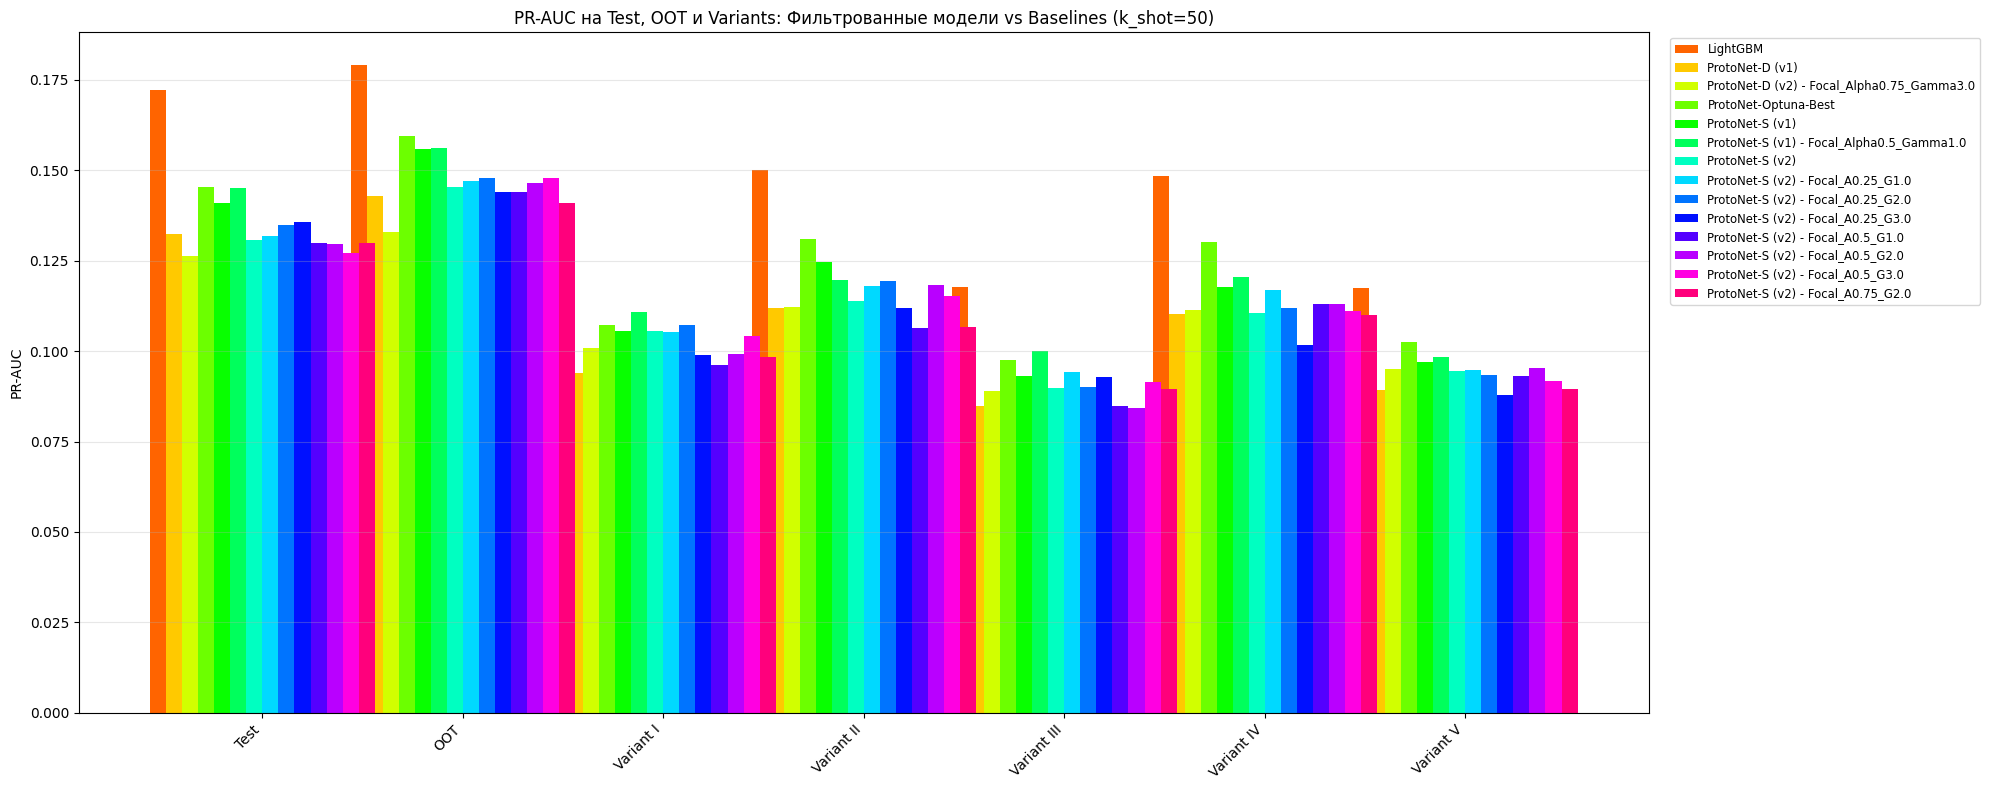

График сохранён: /content/protonet_vs_baseline_prauc_consolidated_filtered_models.png


In [ ]:
variant_names_for_plot = ['Test', 'OOT', 'Variant_I', 'Variant_II', 'Variant_III', 'Variant_IV', 'Variant_V']

# Filter for Variant results and PR-AUC
# Use filtered_pivot_consolidated to only include the desired models
pr_auc_pivot = filtered_pivot_consolidated['pr_auc'].loc[variant_names_for_plot]

x = np.arange(len(variant_names_for_plot))
w = 0.08 # Adjusted bar width for potentially more bars

fig, ax = plt.subplots(figsize=(20, 8)) # Increased figure width for better readability

# Get all unique model names from the filtered pivot table columns
models_to_plot = pr_auc_pivot.columns.tolist()
# Generate a color palette for all models
colors = sns.color_palette("hsv", len(models_to_plot))

for i, model_name in enumerate(models_to_plot):
    if model_name in pr_auc_pivot.columns:
        ax.bar(x + (i - len(models_to_plot)/2 + 0.5) * w, pr_auc_pivot[model_name], w, label=model_name, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([name.replace('_', ' ') for name in variant_names_for_plot], rotation=45, ha='right')
ax.set_ylabel('PR-AUC')
ax.set_title(f'PR-AUC на Test, OOT и Variants: Фильтрованные модели vs Baselines (k_shot={K_SHOT_EVAL})') # Updated title
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/protonet_vs_baseline_prauc_consolidated_filtered_models.png', dpi=150) # New filename
plt.show()
print('График сохранён: /content/protonet_vs_baseline_prauc_consolidated_filtered_models.png')

Топ-5 лучших моделей (по среднему PR-AUC): ['LightGBM', 'ProtoNet-Optuna-Best', 'ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0', 'ProtoNet-S (v1)', 'ProtoNet-S (v2) - Focal_A0.25_G1.0']

=== Сводная таблица метрик (топ-5 лучших моделей) ===
                  f1   pr_auc  roc_auc                   f1               pr_auc              roc_auc                                        f1                                    pr_auc                                   roc_auc              f1          pr_auc         roc_auc                                 f1                             pr_auc                            roc_auc
model       LightGBM LightGBM LightGBM ProtoNet-Optuna-Best ProtoNet-Optuna-Best ProtoNet-Optuna-Best ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0 ProtoNet-S (v1) ProtoNet-S (v1) ProtoNet-S (v1) ProtoNet-S (v2) - Focal_A0.25_G1.0 ProtoNet-S (v2) - Focal_A0.25_G1.0 ProtoNet-S (v2) - Focal_A0.25_G1.0
s

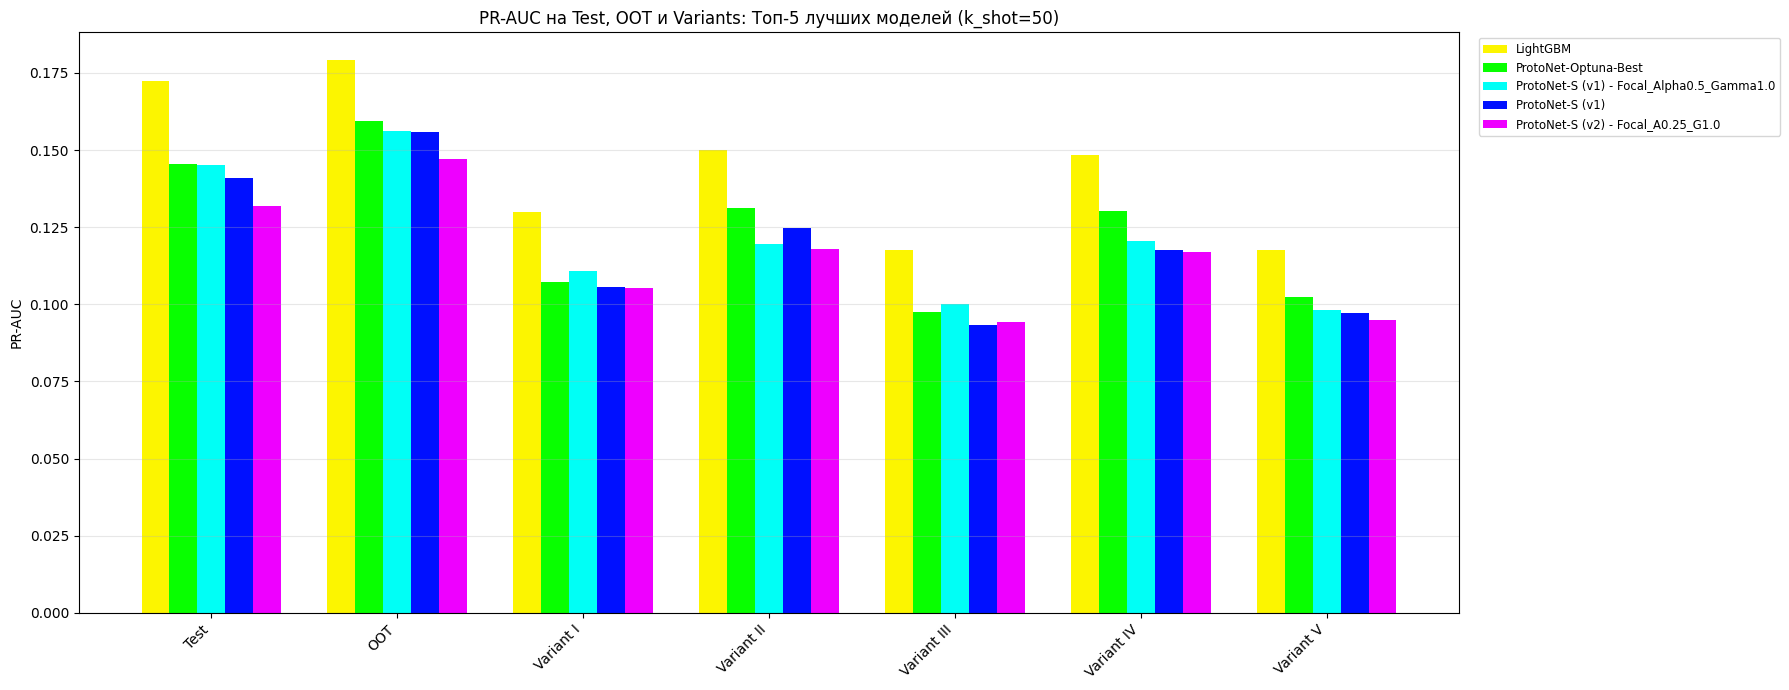

График сохранён: /content/protonet_vs_baseline_prauc_top5_models.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean PR-AUC for each model across all splits, sorting descending for best models
pr_auc_means_overall = pivot_consolidated['pr_auc'].mean().sort_values(ascending=False)

# Identify the 5 best models based on mean PR-AUC
best_5_models = pr_auc_means_overall.head(5).index.tolist()
print(f"Топ-5 лучших моделей (по среднему PR-AUC): {best_5_models}")

# Filter the pivot table to include only these best models
filtered_pivot_consolidated_best = pivot_consolidated.loc[:, (slice(None), best_5_models)]

print('\n=== Сводная таблица метрик (топ-5 лучших моделей) ===')
print(filtered_pivot_consolidated_best.to_string())

# Plotting
variant_names_for_plot = ['Test', 'OOT', 'Variant_I', 'Variant_II', 'Variant_III', 'Variant_IV', 'Variant_V']

# Filter for Variant results and PR-AUC
pr_auc_pivot_best = filtered_pivot_consolidated_best['pr_auc'].loc[variant_names_for_plot]

x = np.arange(len(variant_names_for_plot))
w = 0.15 # Adjusted bar width for 5 bars

fig, ax = plt.subplots(figsize=(18, 7)) # Increased figure width for better readability

# Get all unique model names from the filtered pivot table columns
models_to_plot_best = pr_auc_pivot_best.columns.tolist()
# Generate a color palette for all models
colors = sns.color_palette("hsv", len(models_to_plot_best))

for i, model_name in enumerate(models_to_plot_best):
    if model_name in pr_auc_pivot_best.columns:
        ax.bar(x + (i - len(models_to_plot_best)/2 + 0.5) * w, pr_auc_pivot_best[model_name], w, label=model_name, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([name.replace('_', ' ') for name in variant_names_for_plot], rotation=45, ha='right')
ax.set_ylabel('PR-AUC')
ax.set_title(f'PR-AUC на Test, OOT и Variants: Топ-5 лучших моделей (k_shot={K_SHOT_EVAL})') # Updated title
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/protonet_vs_baseline_prauc_top5_models.png', dpi=150) # New filename
plt.show()
print('График сохранён: /content/protonet_vs_baseline_prauc_top5_models.png')

### Анализ стабильности лучших моделей на Variant-выборках

Проанализируем стабильность топ-5 лучших моделей, оценив разброс (стандартное отклонение) их метрики PR-AUC по различным Variant-выборкам (от Variant I до Variant V).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Извлечение PR-AUC для Variants для топ-5 моделей
variant_splits = [f'Variant_{name}' for name in VARIANT_NAMES]

# Фильтрация результатов для топ-5 моделей и только для Variant-выборок
pr_auc_variants_top5 = filtered_pivot_consolidated_best['pr_auc'].loc[variant_splits]

# Перевод индексов в список для удобства
pr_auc_variants_top5_df = pr_auc_variants_top5.reset_index()
pr_auc_variants_top5_df = pr_auc_variants_top5_df.melt(id_vars='split', var_name='model', value_name='pr_auc')

# Вычисление среднего PR-AUC и стандартного отклонения для каждой модели
stability_metrics = pr_auc_variants_top5_df.groupby('model')['pr_auc'].agg(['mean', 'std']).sort_values(by='mean', ascending=False).reset_index()
stability_metrics = stability_metrics.rename(columns={'mean': 'mean_pr_auc_variants', 'std': 'std_pr_auc_variants'})

print("\nСтабильность топ-5 моделей (PR-AUC на Variant-выборках):")
print(stability_metrics.to_string())

# Сохранение результатов
stability_metrics.to_csv('/content/top5_model_stability_variants.csv', index=False)
print('\nСохранено: /content/top5_model_stability_variants.csv')


Стабильность топ-5 моделей (PR-AUC на Variant-выборках):
                                       model  mean_pr_auc_variants  std_pr_auc_variants
0                                   LightGBM               0.13272             0.015886
1                       ProtoNet-Optuna-Best               0.11370             0.015808
2  ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0               0.10988             0.010486
3                            ProtoNet-S (v1)               0.10762             0.013351
4         ProtoNet-S (v2) - Focal_A0.25_G1.0               0.10584             0.011412

Сохранено: /content/top5_model_stability_variants.csv


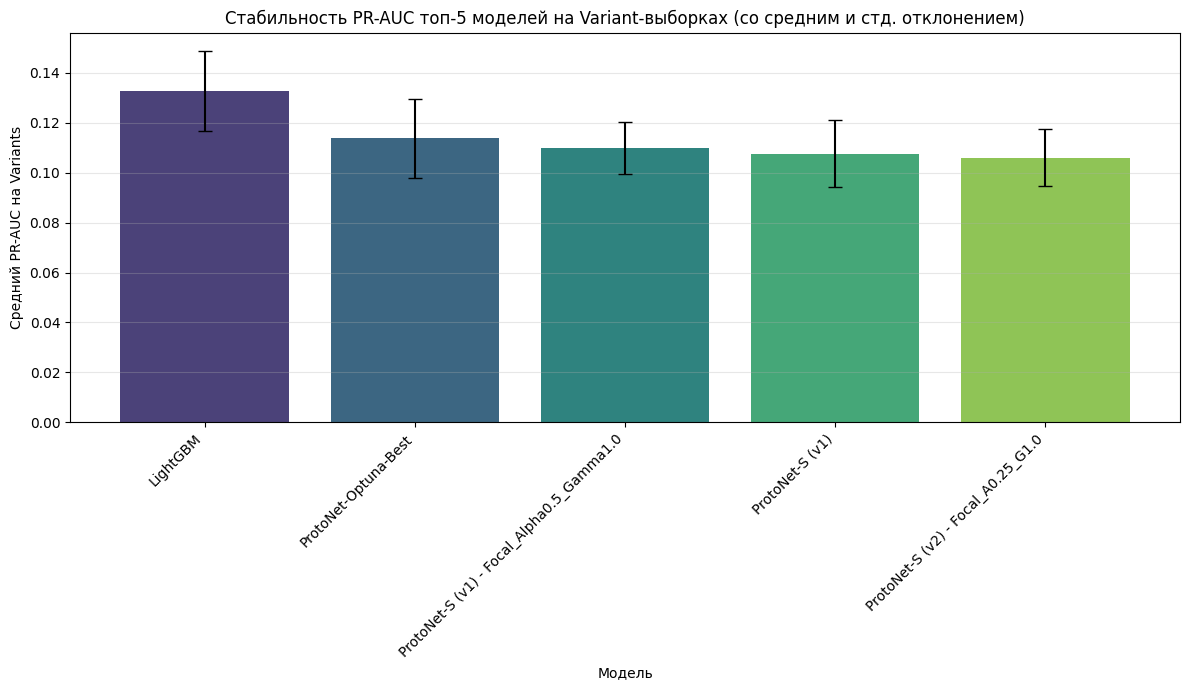

График сохранён: /content/top5_model_stability_variants.png


In [ ]:
import numpy as np

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='model',
    y='mean_pr_auc_variants',
    data=stability_metrics,
    palette='viridis',
    capsize=0.1 # Capsize is now handled by plt.errorbar
)

# Get the bar positions and heights
x_coords = [p.get_x() + p.get_width() / 2 for p in ax.patches]
y_heights = [p.get_height() for p in ax.patches]

# Get the error values
std_devs = stability_metrics['std_pr_auc_variants'].to_numpy()

# Add error bars manually
ax.errorbar(
    x=x_coords,
    y=y_heights,
    yerr=std_devs, # yerr here is a 1D array matching the number of bars
    fmt='none', # Do not plot lines connecting the error bars
    c='black', # Color of error bars
    capsize=5 # Adjust capsize as needed for error bars
)

plt.title('Стабильность PR-AUC топ-5 моделей на Variant-выборках (со средним и стд. отклонением)')
plt.xlabel('Модель')
plt.ylabel('Средний PR-AUC на Variants')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/top5_model_stability_variants.png', dpi=150)
plt.show()
print('График сохранён: /content/top5_model_stability_variants.png')

### Распределение ROC-AUC и F1 для топ-5 моделей на всех выборках

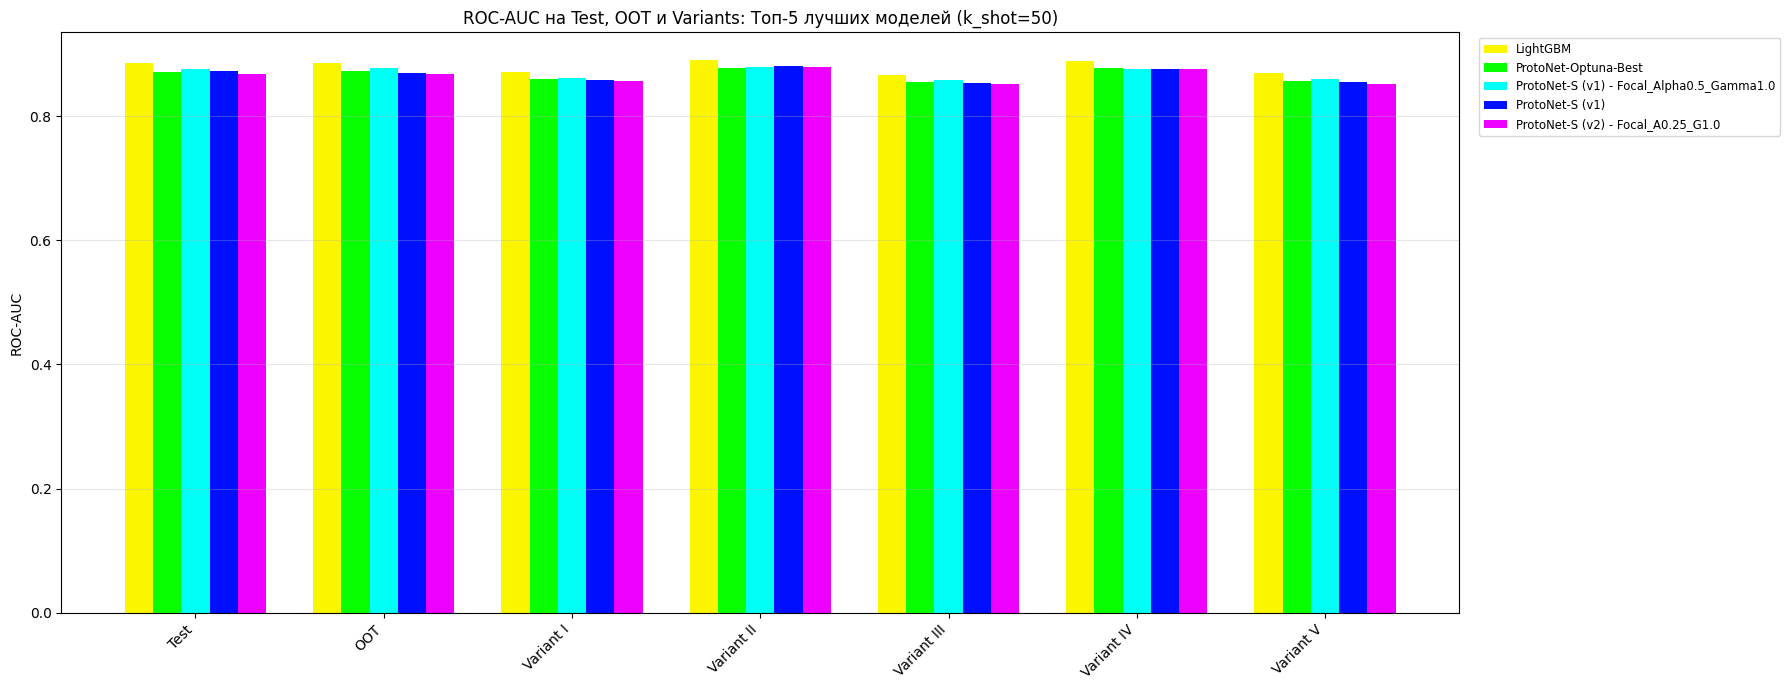

График ROC-AUC сохранён: /content/protonet_vs_baseline_roc_auc_top5_models.png


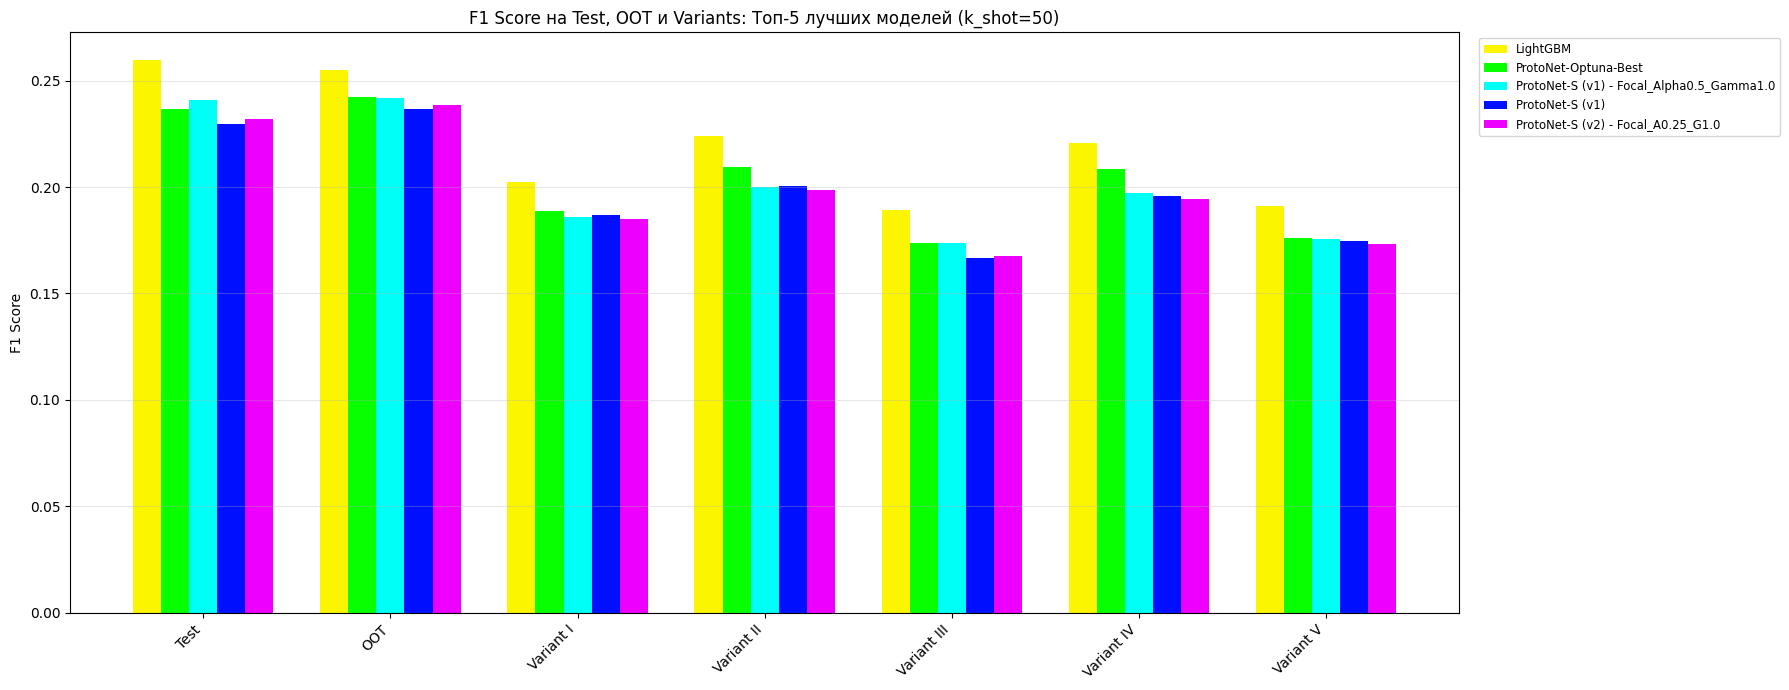

График F1 Score сохранён: /content/protonet_vs_baseline_f1_top5_models.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter the consolidated results for the top-5 models and relevant splits
# `filtered_pivot_consolidated_best` already contains only the top-5 models
# `variant_names_for_plot` includes 'Test', 'OOT', and all 'Variant_X'

# Prepare data for plotting ROC-AUC and F1
roc_auc_pivot_best = filtered_pivot_consolidated_best['roc_auc'].loc[variant_names_for_plot]
f1_pivot_best = filtered_pivot_consolidated_best['f1'].loc[variant_names_for_plot]

models_to_plot_best = roc_auc_pivot_best.columns.tolist()
colors = sns.color_palette("hsv", len(models_to_plot_best))

x = np.arange(len(variant_names_for_plot))
w = 0.15 # Adjusted bar width for 5 bars

# Plot ROC-AUC
fig_roc, ax_roc = plt.subplots(figsize=(18, 7))
for i, model_name in enumerate(models_to_plot_best):
    ax_roc.bar(x + (i - len(models_to_plot_best)/2 + 0.5) * w, roc_auc_pivot_best[model_name], w, label=model_name, color=colors[i])

ax_roc.set_xticks(x)
ax_roc.set_xticklabels([name.replace('_', ' ') for name in variant_names_for_plot], rotation=45, ha='right')
ax_roc.set_ylabel('ROC-AUC')
ax_roc.set_title(f'ROC-AUC на Test, OOT и Variants: Топ-5 лучших моделей (k_shot={K_SHOT_EVAL})')
ax_roc.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')
ax_roc.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/protonet_vs_baseline_roc_auc_top5_models.png', dpi=150)
plt.show()
print('График ROC-AUC сохранён: /content/protonet_vs_baseline_roc_auc_top5_models.png')

# Plot F1 Score
fig_f1, ax_f1 = plt.subplots(figsize=(18, 7))
for i, model_name in enumerate(models_to_plot_best):
    ax_f1.bar(x + (i - len(models_to_plot_best)/2 + 0.5) * w, f1_pivot_best[model_name], w, label=model_name, color=colors[i])

ax_f1.set_xticks(x)
ax_f1.set_xticklabels([name.replace('_', ' ') for name in variant_names_for_plot], rotation=45, ha='right')
ax_f1.set_ylabel('F1 Score')
ax_f1.set_title(f'F1 Score на Test, OOT и Variants: Топ-5 лучших моделей (k_shot={K_SHOT_EVAL})')
ax_f1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')
ax_f1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/protonet_vs_baseline_f1_top5_models.png', dpi=150)
plt.show()
print('График F1 Score сохранён: /content/protonet_vs_baseline_f1_top5_models.png')

### Анализ стабильности ROC-AUC и F1 для топ-5 моделей на Variant-выборках

### Тепловая карта корреляции производительности моделей на Variant-выборках (PR-AUC)

Эта тепловая карта визуализирует корреляцию производительности (PR-AUC) каждой пары моделей на Variant-выборках. Высокие значения корреляции (близкие к 1) показывают, что модели ведут себя схожим образом на разных вариантах, тогда как низкие значения (близкие к 0 или отрицательные) указывают на различное поведение.

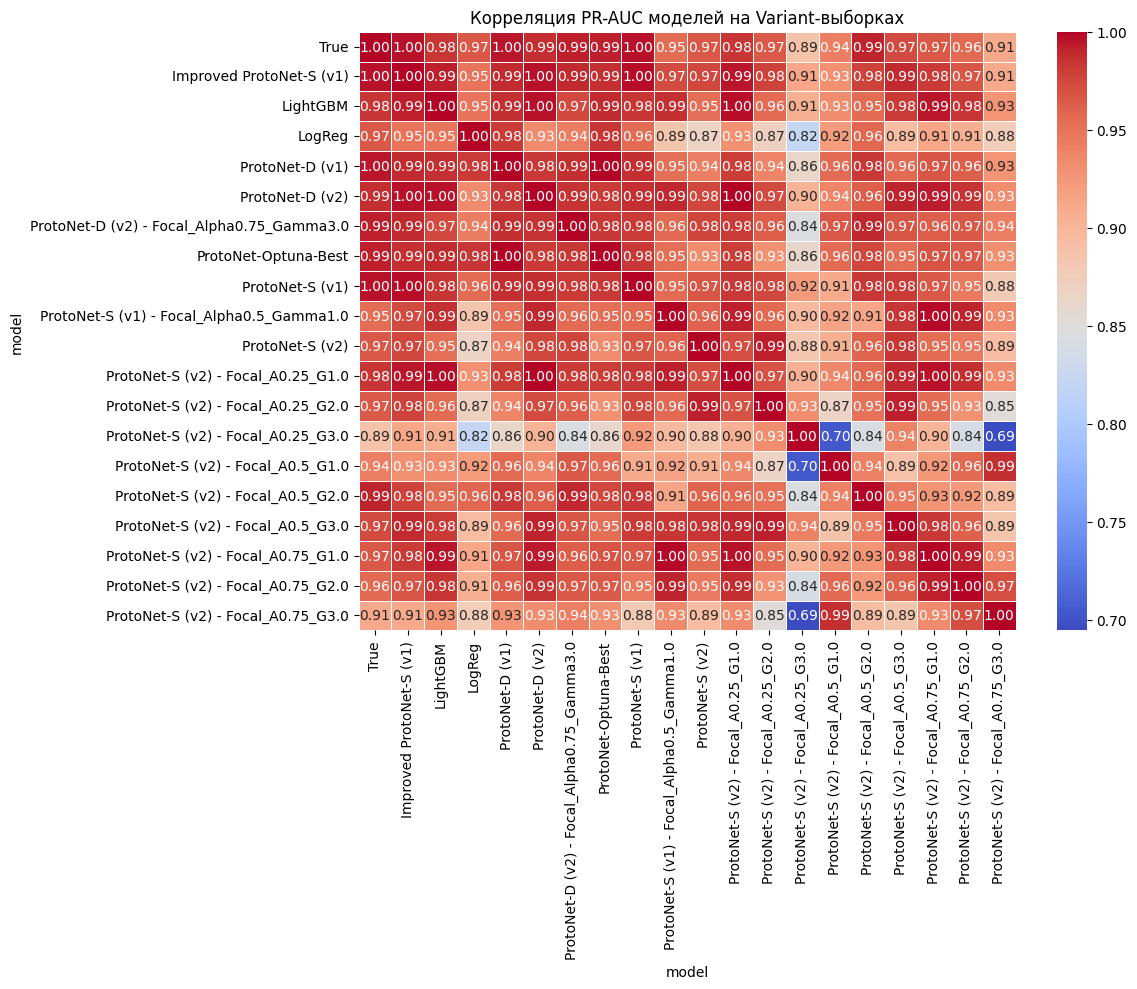

Тепловая карта корреляции сохранена: /content/correlation_heatmap_pr_auc_variants.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for Variant splits and PR-AUC
variant_splits_only = [f'Variant_{name}' for name in VARIANT_NAMES]
pr_auc_variants_all_models = results_df_consolidated[
    (results_df_consolidated['split'].isin(variant_splits_only))
].pivot_table(index='split', columns='model', values='pr_auc')

# Calculate the correlation matrix
correlation_matrix = pr_auc_variants_all_models.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляция PR-AUC моделей на Variant-выборках')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/correlation_heatmap_pr_auc_variants.png', dpi=150)
plt.show()

print('Тепловая карта корреляции сохранена: /content/correlation_heatmap_pr_auc_variants.png')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract ROC-AUC and F1 for Variants for the top-5 models
variant_splits = [f'Variant_{name}' for name in VARIANT_NAMES]

# Filter for ROC-AUC
roc_auc_variants_top5 = filtered_pivot_consolidated_best['roc_auc'].loc[variant_splits]
roc_auc_variants_top5_df = roc_auc_variants_top5.reset_index()
roc_auc_variants_top5_df = roc_auc_variants_top5_df.melt(id_vars='split', var_name='model', value_name='roc_auc')

# Calculate mean and std dev for ROC-AUC
stability_roc_auc = roc_auc_variants_top5_df.groupby('model')['roc_auc'].agg(['mean', 'std']).sort_values(by='mean', ascending=False).reset_index()
stability_roc_auc = stability_roc_auc.rename(columns={'mean': 'mean_roc_auc_variants', 'std': 'std_roc_auc_variants'})

print("\nСтабильность топ-5 моделей (ROC-AUC на Variant-выборках):")
print(stability_roc_auc.to_string())

# Save results
stability_roc_auc.to_csv('/content/top5_model_stability_roc_auc.csv', index=False)
print('\nСохранено: /content/top5_model_stability_roc_auc.csv')

# Filter for F1 Score
f1_variants_top5 = filtered_pivot_consolidated_best['f1'].loc[variant_splits]
f1_variants_top5_df = f1_variants_top5.reset_index()
f1_variants_top5_df = f1_variants_top5_df.melt(id_vars='split', var_name='model', value_name='f1')

# Calculate mean and std dev for F1 Score
stability_f1 = f1_variants_top5_df.groupby('model')['f1'].agg(['mean', 'std']).sort_values(by='mean', ascending=False).reset_index()
stability_f1 = stability_f1.rename(columns={'mean': 'mean_f1_variants', 'std': 'std_f1_variants'})

print("\nСтабильность топ-5 моделей (F1 Score на Variant-выборках):")
print(stability_f1.to_string())

# Save results
stability_f1.to_csv('/content/top5_model_stability_f1.csv', index=False)
print('\nСохранено: /content/top5_model_stability_f1.csv')


Стабильность топ-5 моделей (ROC-AUC на Variant-выборках):
                                       model  mean_roc_auc_variants  std_roc_auc_variants
0                                   LightGBM                0.87716              0.011514
1  ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0                0.86712              0.009837
2                       ProtoNet-Optuna-Best                0.86518              0.011663
3                            ProtoNet-S (v1)                0.86466              0.012805
4         ProtoNet-S (v2) - Focal_A0.25_G1.0                0.86318              0.013266

Сохранено: /content/top5_model_stability_roc_auc.csv

Стабильность топ-5 моделей (F1 Score на Variant-выборках):
                                       model  mean_f1_variants  std_f1_variants
0                                   LightGBM           0.20554         0.016158
1                       ProtoNet-Optuna-Best           0.19126         0.017117
2  ProtoNet-S (v1) - Focal_Alpha0.5_Gamma1.0   

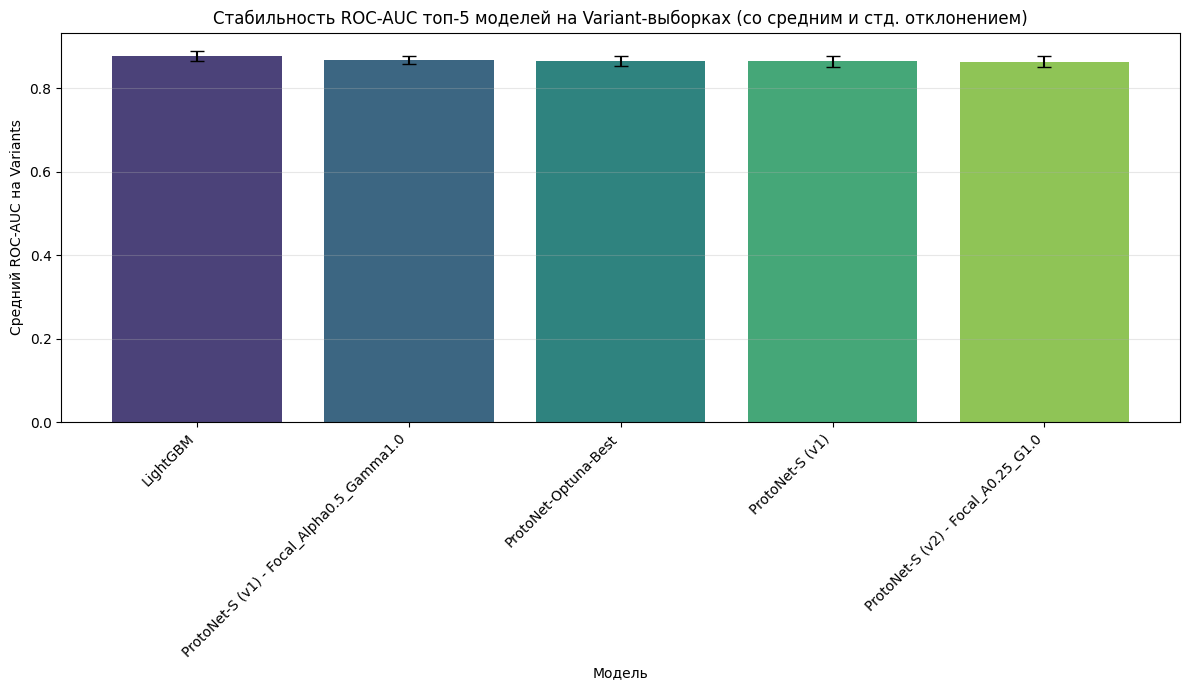

График стабильности ROC-AUC сохранён: /content/top5_model_stability_roc_auc_plot.png


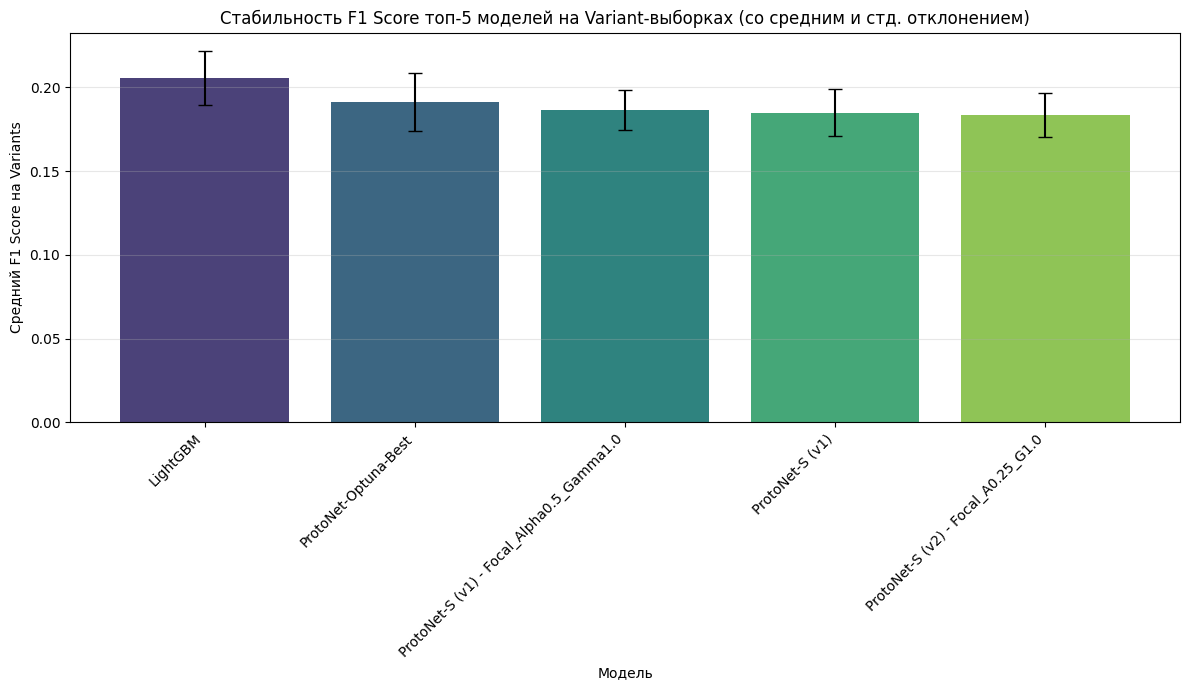

График стабильности F1 Score сохранён: /content/top5_model_stability_f1_plot.png


In [ ]:
import numpy as np

# Plot stability for ROC-AUC
plt.figure(figsize=(12, 7))
ax_roc_stab = sns.barplot(
    x='model',
    y='mean_roc_auc_variants',
    data=stability_roc_auc,
    palette='viridis',
    capsize=0.1
)
x_coords_roc = [p.get_x() + p.get_width() / 2 for p in ax_roc_stab.patches]
y_heights_roc = [p.get_height() for p in ax_roc_stab.patches]
std_devs_roc = stability_roc_auc['std_roc_auc_variants'].to_numpy()
ax_roc_stab.errorbar(
    x=x_coords_roc,
    y=y_heights_roc,
    yerr=std_devs_roc,
    fmt='none',
    c='black',
    capsize=5
)
plt.title('Стабильность ROC-AUC топ-5 моделей на Variant-выборках (со средним и стд. отклонением)')
plt.xlabel('Модель')
plt.ylabel('Средний ROC-AUC на Variants')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/top5_model_stability_roc_auc_plot.png', dpi=150)
plt.show()
print('График стабильности ROC-AUC сохранён: /content/top5_model_stability_roc_auc_plot.png')

# Plot stability for F1 Score
plt.figure(figsize=(12, 7))
ax_f1_stab = sns.barplot(
    x='model',
    y='mean_f1_variants',
    data=stability_f1,
    palette='viridis',
    capsize=0.1
)
x_coords_f1 = [p.get_x() + p.get_width() / 2 for p in ax_f1_stab.patches]
y_heights_f1 = [p.get_height() for p in ax_f1_stab.patches]
std_devs_f1 = stability_f1['std_f1_variants'].to_numpy()
ax_f1_stab.errorbar(
    x=x_coords_f1,
    y=y_heights_f1,
    yerr=std_devs_f1,
    fmt='none',
    c='black',
    capsize=5
)
plt.title('Стабильность F1 Score топ-5 моделей на Variant-выборках (со средним и стд. отклонением)')
plt.xlabel('Модель')
plt.ylabel('Средний F1 Score на Variants')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/top5_model_stability_f1_plot.png', dpi=150)
plt.show()
print('График стабильности F1 Score сохранён: /content/top5_model_stability_f1_plot.png')

## Сохранение всех артефактов

In [ ]:
import json

# Веса моделей
torch.save(model_s.state_dict(), '/content/protonet_mlp_s_final.pt')
torch.save(model_d.state_dict(), '/content/protonet_mlp_d_final.pt')

# Loss-кривые
with open('/content/losses_mlp_s.json', 'w') as f:
    json.dump(losses_s, f)
with open('/content/losses_mlp_d.json', 'w') as f:
    json.dump(losses_d, f)

# Результаты по вариантам
pd.DataFrame(results_var_s).to_csv('/content/results_var_mlp_s.csv', index=False)
pd.DataFrame(results_var_d).to_csv('/content/results_var_mlp_d.csv', index=False)

print('=== Все артефакты сохранены в /content/ ===')
print('Файлы для скачивания:')
artifacts = [
    'protonet_mlp_s_final.pt',
    'protonet_mlp_d_final.pt',
    'results_protonet_vs_baseline.csv',
    'results_protonet_pivot.csv',
    'kshot_sensitivity.csv',
    'protonet_loss_curve.png',
    'protonet_vs_baseline_prauc.png',
]
for a in artifacts:
    print(f'  /content/{a}')

=== Все артефакты сохранены в /content/ ===
Файлы для скачивания:
  /content/protonet_mlp_s_final.pt
  /content/protonet_mlp_d_final.pt
  /content/results_protonet_vs_baseline.csv
  /content/results_protonet_pivot.csv
  /content/kshot_sensitivity.csv
  /content/protonet_loss_curve.png
  /content/protonet_vs_baseline_prauc.png


In [ ]:
# Опционально: скачать все ключевые файлы одной командой
from google.colab import files

for fname in [
    '/content/results_protonet_vs_baseline.csv',
    '/content/results_protonet_pivot.csv',
    '/content/kshot_sensitivity.csv',
    '/content/protonet_loss_curve.png',
    '/content/protonet_vs_baseline_prauc.png',
]:
    files.download(fname)

---
## Что дальше (фаза 3, 18–24 апр)

По расписанию следующий шаг — добавление **MAML / FOMAML** для сравнения методов.  
Ноутбук `04_maml.ipynb` будет содержать:
- Реализацию FOMAML (First-Order MAML) — более простой вариант для начала
- Тот же цикл meta-train / meta-test на тех же данных
- Итоговую таблицу: ProtoNet-S vs ProtoNet-D vs MAML vs LightGBM vs LogReg

**Текущий статус чекпоинта:** если ProtoNet запущен и даёт результаты на Variants,  
фаза 3 (первая половина) закрыта ✓